# MoE Rebuttal Notebook — subject-level routing analysis

Single source of truth for the NeurIPS rebuttal. Replaces the three-way split across
`ALL_USERS` / `ALL_USERS_FAST` / `WITHHELD_USERS`.

**Reviewer question being answered:**
> *"Have you done a subject-level (not ability level) routing analysis? Since number of
> experts is not very small compared to number of subjects, how do you make sure that
> there is no single expert for at least some of the subjects?"*

### Design decisions (read before running)

1. **One collection pass, two populations.** Routing is collected once over all 32
   subjects; the withheld-8 population is derived by masking on PID. Same model, same
   episode budget, no re-collection. Everything downstream is reported for both.
2. **Balanced episodes per subject.** Collection is throttled to `EPISODES_PER_USER`
   for every subject. This is *required* — the exclusivity lower bound in Claim D
   divides selection frequency by each subject's sample share, so unbalanced counts
   silently break it. Balance is asserted after collection.
3. **Paired pre/post-adaptation collection.** Both are recorded on identical episodes so
   the "does adaptation move the gate?" question is answered by a controlled paired
   comparison (Claim G) instead of an assumption. This matters: `mamlpp_adapt` calls
   `named_param_dict(model, require_grad_only=True)`, which excludes only `_lslr.*` —
   the router and its projector **do** receive all 10 inner-loop updates. The
   `ALL_USERS_FAST` notebook's stated rationale for skipping adaptation ("MAML updates
   the head + LSLR step sizes") is incorrect.
4. **`model.eval()` is forced before every query forward pass.** `mamlpp_adapt` sets
   `model.train()` internally and does not restore eval. In the existing notebooks the
   `model.eval()` call sits at the end of the *outer* `for step_item` loop, so every
   post-adaptation routing forward pass after the first episode in a batch ran with
   **dropout active** (`dropout=0.1`, `MOE_dropout=0.0225`). That inflates routing
   entropy and adds noise to the gate vectors. Expect the numbers here to differ from
   the old notebooks; these are the correct ones.
5. **No dependency on `load_balance()` dict keys.** `ALL_USERS` reads
   `lb['expert_hard_fraction']` / `lb['ideal_fraction']` / `lb['hard_imbalance_ratio']`,
   but the current `MOE_analysis.py` returns `expert_dominant_freq` /
   `ideal_selection_fraction` / `dominant_imbalance_ratio`. The module has drifted from
   the notebooks. Every statistic here is computed directly from
   `record.gate_weights` / `.pids` / `.gesture_labels`, so nothing breaks silently.
6. **E=22, top_k=9** are asserted against the checkpoint and re-verified empirically
   from the gate vectors. The `num_experts: 24, MOE_top_k: 7` values in the old notebook
   config dicts are stale and are discarded by `del config` anyway.

### Reference values you will need when reading the output

| Statistic | Dedicated-expert regime gives | Permutation null gives | Direction |
|---|---|---|---|
| Private-expert margin (max over subjects) | ~1.0 | small | high = dedication |
| Subject concentration (max subject-mean weight) | ~1.0 | ~1/k, inflated by the max | high = dedication |
| Expert ownership (top subject's share of an expert's mass) | ~1.0 | **not** 1/32 — inflated, see 11b | high = dedication |
| Subject-vector cosine similarity (mean pairwise) | ~0.0 | ~1.0 | **low** = dedication |
| Subjects per expert (min) | 1 | n_subjects | low = dedication |
| eta² subject | ~1.0 | ~0.0 | high = dedication |

Two traps, both verified on synthetic data before this notebook was written:

- **Top-k set overlap does not work and is not used as evidence.** Under a dedicated-expert
  regime a subject's top-9 is its one private expert plus the eight generically-best
  experts, so set overlap *rises* to ~7.8/9 — higher than a genuine shared-pool regime
  (~5.4/9). It is reported in Claim D as a descriptive only, flagged non-diagnostic.
- **Max-statistics have inflated nulls.** Expert ownership is a max over E experts of a max
  over S subjects, so its permutation null sits around 0.24–0.36, not 1/32 = 0.031.
  Quote the max against the permutation null (11b) and the *median* against the uniform
  reference. Quoting max against 1/32 overstates the result and a reviewer can reproduce it.

### Run order

Cells run top to bottom. Section 5 is the only slow cell; it saves both records, so
set `RELOAD_RECORDS = True` on subsequent runs and skip straight to Section 6.

## 1. Imports and paths

In [1]:
import sys, os, json, math, pickle, warnings, itertools
from pathlib import Path
from collections import defaultdict

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['font.size'] = 9
warnings.filterwarnings('ignore', category=UserWarning)

# ── Paths ────────────────────────────────────────────────────────────────────
PROJECT_ROOT     = r"C:\Users\kdmen\Repos\pers-gest-cls\system"
SPLIT_JSON_PATH  = r"C:\Users\kdmen\Repos\pers-gest-cls\system\fixed_user_splits\hpo_strat_kapanji_split.json"
TENSOR_DICT_PATH = r"C:\Users\kdmen\Repos\pers-gest-cls\dataset\meta-learning-sup-que-ds\segfilt_withMorphology_tensor_dict.pkl"
CHECKPOINT_PATH  = r"C:\Users\kdmen\Repos\pers-gest-cls\models\final_eval_models\best_M0_model.pt"
OUT_DIR          = Path(r"C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RECORD_POST_PATH = OUT_DIR / "rebuttal_record_post_adapt.pt"
RECORD_PRE_PATH  = OUT_DIR / "rebuttal_record_pre_adapt.pt"

# ── Run controls ─────────────────────────────────────────────────────────────
FOLD_KEY            = 0
EPISODES_PER_USER   = 50      # balanced across all 32 subjects. 50 x 27 = 1350 samples/subject
RELOAD_RECORDS      = False   # True on re-runs -> skips the slow collection cell
COLLECT_PRE_ADAPT   = True    # paired pre-adapt pass for Claim G
SAVE_FIGS           = True
RANDOM_SEED         = 42

# Architecture the paper reports. Asserted against the checkpoint below.
PAPER_E    = 22
PAPER_TOPK = 9

sys.path.insert(0, PROJECT_ROOT)

from MOE.MOE_encoder  import build_MOE_model
from MOE.MOE_analysis import (RoutingCollector, RoutingAnalyzer, RoutingRecord,
                              save_routing_record, load_routing_record)
from MAML.mamlpp      import (mamlpp_adapt, _normalize_step_item,
                              named_param_dict, FunctionalModel)
from MAML.maml_data_pipeline import get_maml_dataloaders

rng = np.random.default_rng(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# CLAIMS is populated by every section and rendered as rebuttal prose in Section 16.
CLAIMS = {}

print(f"Imports OK | torch {torch.__version__} | CUDA {torch.cuda.is_available()}")
print(f"Output dir: {OUT_DIR}")

Imports OK | torch 2.7.1+cu128 | CUDA False
Output dir: C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal


## 2. Splits and Kapanji groups

In [2]:
KAPANJI_GROUPS = {
    'Non-disabled Kapanji': {'P011', 'P010', 'P008', 'P006', 'P005', 'P004'},
    'Disabled Kapanji':     {'P111', 'P119', 'P124', 'P110', 'P112', 'P123',
                             'P132', 'P126', 'P131', 'P104', 'P116'},
    'Disabled Non-Kapanji': {'P102', 'P114', 'P107', 'P103', 'P125', 'P127',
                             'P128', 'P118', 'P108', 'P122', 'P106', 'P115',
                             'P105', 'P109', 'P121'},
}
GROUP_ABBREV = {'Non-disabled Kapanji': 'NDK',
                'Disabled Kapanji':     'DK',
                'Disabled Non-Kapanji': 'DNK'}

with open(SPLIT_JSON_PATH, 'r') as f:
    split_data = json.load(f)

fold        = split_data[FOLD_KEY]
TRAIN_PIDS  = sorted(fold['train'])
HP_VAL_PIDS = sorted(fold['val'])
TEST_PIDS   = sorted(fold['test'])
WITHHELD_PIDS = sorted(set(HP_VAL_PIDS) | set(TEST_PIDS))
ALL_PIDS      = sorted(set(TRAIN_PIDS) | set(WITHHELD_PIDS))

assert not (set(TRAIN_PIDS) & set(WITHHELD_PIDS)), "PID leakage between train and withheld!"

pid_to_kapanji = {p: g for g, ps in KAPANJI_GROUPS.items() for p in ps}
unassigned = set(ALL_PIDS) - set(pid_to_kapanji)
assert not unassigned, f"PIDs with no Kapanji group: {sorted(unassigned)}"

print(f"Train    ({len(TRAIN_PIDS)}): {TRAIN_PIDS}")
print(f"HP-val   ({len(HP_VAL_PIDS)}): {HP_VAL_PIDS}")
print(f"Test     ({len(TEST_PIDS)}): {TEST_PIDS}")
print(f"Withheld ({len(WITHHELD_PIDS)}): {WITHHELD_PIDS}")
print(f"All      ({len(ALL_PIDS)})")

print("\nKapanji membership by split:")
for g in KAPANJI_GROUPS:
    tr = sorted(set(TRAIN_PIDS) & KAPANJI_GROUPS[g])
    wh = sorted(set(WITHHELD_PIDS) & KAPANJI_GROUPS[g])
    print(f"  {g:<24} train n={len(tr):<3} withheld n={len(wh):<3} {wh}")

CLAIMS['n_subjects_all']      = len(ALL_PIDS)
CLAIMS['n_subjects_train']    = len(TRAIN_PIDS)
CLAIMS['n_subjects_withheld'] = len(WITHHELD_PIDS)

Train    (24): ['P006', 'P008', 'P010', 'P011', 'P102', 'P103', 'P106', 'P107', 'P108', 'P110', 'P111', 'P112', 'P114', 'P115', 'P118', 'P119', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P132']
HP-val   (4): ['P005', 'P109', 'P116', 'P131']
Test     (4): ['P004', 'P104', 'P105', 'P121']
Withheld (8): ['P004', 'P005', 'P104', 'P105', 'P109', 'P116', 'P121', 'P131']
All      (32)

Kapanji membership by split:
  Non-disabled Kapanji     train n=4   withheld n=2   ['P004', 'P005']
  Disabled Kapanji         train n=8   withheld n=3   ['P104', 'P116', 'P131']
  Disabled Non-Kapanji     train n=12  withheld n=3   ['P105', 'P109', 'P121']


## 3. Load checkpoint and verify architecture

In [3]:
def load_maml_checkpoint(checkpoint_path: Path):
    print(f"Loading MAML checkpoint: {checkpoint_path}")
    assert checkpoint_path.exists(), f"Checkpoint not found: {checkpoint_path}"

    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    cfg  = ckpt["config"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    cfg["device"] = device

    if cfg["use_MOE"]:
        model = build_MOE_model(cfg)
    else:
        from pretraining.pretrain_models import build_model
        model = build_model(cfg)

    if cfg.get("maml_use_lslr", False):
        from MAML.mamlpp import PerParamPerStepLSLR
        temp_params = named_param_dict(model, require_grad_only=True)
        model._lslr = PerParamPerStepLSLR(
            named_params=temp_params.items(),
            inner_steps=cfg["maml_inner_steps"],
            init_lr=cfg["maml_alpha_init"],
            learnable=True, device=device,
        ).to(device)

    raw_sd, remapped_sd, n_remapped = ckpt["model_state_dict"], {}, 0
    for k, v in raw_sd.items():
        nk = k.replace("ctx_proj.", "router.projector.").replace("ctx_proj-", "router-projector-")
        if nk != k:
            n_remapped += 1
        remapped_sd[nk] = v
    if n_remapped:
        print(f"  [ckpt remap] {n_remapped} keys: ctx_proj -> router.projector")

    model.load_state_dict(remapped_sd)
    model.to(device).eval()
    print(f"  Best val acc: {ckpt.get('best_val_acc', 'N/A')}")
    return model, cfg


model, config = load_maml_checkpoint(Path(CHECKPOINT_PATH))

# Fields not persisted in the checkpoint
config['demo_dim_labels'] = [
    'time_disabled', 'age', 'BMI', 'DASH_score',
    'disability_coding_MD', 'disability_coding_No_Disability',
    'disability_coding_PN', 'disability_coding_SCI', 'disability_coding_other',
    'handedness_Right', 'gender_Non-binary', 'gender_Woman',
]
config['num_eval_episodes']         = 200   # dataloader supply; we throttle downstream
config['train_PIDs']                = []
config['val_PIDs']                  = ALL_PIDS
config['user_split_json_filepath']  = SPLIT_JSON_PATH

E      = int(config['num_experts'])
TOPK   = int(config['MOE_top_k'])
device = config['device']

# Hard stop if the checkpoint disagrees with what the paper reports.
assert E == PAPER_E, f"Checkpoint E={E} but paper reports {PAPER_E}"
assert TOPK == PAPER_TOPK, f"Checkpoint top_k={TOPK} but paper reports {PAPER_TOPK}"

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: {config['model_type']} (MoE encoder) | {n_params:,} params")
print(f"E={E}, top_k={TOPK} | ideal selection freq = k/E = {TOPK/E:.4f}")
print(f"aux load-balance coeff = {config.get('MOE_aux_coeff')} "
      f"(applied: {config.get('apply_MOE_aux_loss_inner_outer')})")
print(f"gate_type = {config.get('gate_type')} | inner steps @ eval = {config.get('maml_inner_steps_eval')}")

CLAIMS.update(E=E, TOPK=TOPK, ideal_sel=TOPK/E, n_params=n_params,
              aux_coeff=config.get('MOE_aux_coeff'),
              random_overlap_ref=TOPK**2 / E,
              uniform_weight_ref=1.0 / TOPK,
              uniform_ownership_ref=1.0 / len(ALL_PIDS))

Loading MAML checkpoint: C:\Users\kdmen\Repos\pers-gest-cls\models\final_eval_models\best_M0_model.pt
  Best val acc: 0.9066927083333334

Model: DeepCNNLSTM (MoE encoder) | 5,538,216 params
E=22, top_k=9 | ideal selection freq = k/E = 0.4091
aux load-balance coeff = 0.03282324399711515 (applied: outer)
gate_type = context_feature_demo | inner steps @ eval = 10


## 3b. Restore data-pipeline config keys

The checkpoint's saved config does **not** contain the episode/dataloader keys.
In the older notebooks this was invisible because `get_maml_dataloaders` was called on
the hand-written config dict *before* `del config` swapped in the checkpoint's config;
calling it on the checkpoint config directly raises `KeyError: 'target_trial_reps'`.

The required key list below was read out of `maml_data_pipeline.py` (bracket access, so
no defaults), plus the keys `mamlpp_adapt` needs at eval time. Values come from the
hand-written config in `MOE_routing_analysis_WITHHELD_USERS.ipynb`.

`setdefault` is used deliberately: **the checkpoint always wins** where it has a value, so
this cannot silently reintroduce a stale hyperparameter. Anything actually injected is
printed. Note the checkpoint's `MOE_aux_coeff` differs from the old notebook dicts, which
is exactly the kind of drift this ordering protects against.

In [4]:
# Values sourced from the hand-written config in the WITHHELD_USERS notebook.
DATA_PIPELINE_DEFAULTS = {
    # ── episode sampling / dataloader ────────────────────────────────────────
    'maml_gesture_classes':     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    'target_trial_reps':        None,          # None -> all available trials
    'train_reps':               [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'val_reps':                 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'episodes_per_epoch_train': 250,
    'num_workers':              0,
    'use_label_shuf_meta_aug':  False,
    'seed':                     RANDOM_SEED,
    'subject_specific_model':   False,
    'debug_one_episode':        False,
    'debug_five_episodes':      False,
    'debug_one_user_only':      False,
    'debug_verbose':            False,
    # ── episode shape ────────────────────────────────────────────────────────
    'n_way': 3, 'k_shot': 1, 'q_query': 9,
    # ── input channels (reorient_tensor_dict reads these) ────────────────────
    'emg_in_ch': 16, 'imu_in_ch': 72,
    'multimodal': True, 'use_imu': True,
    'sequence_length': 64, 'augment': False, 'feature_engr': None, 'padding': 0,
    # ── needed by mamlpp_adapt at eval time ─────────────────────────────────
    'maml_inner_steps_eval':  10,
    'maml_alpha_init_eval':   0.006717556958813548,
    'maml_use_lslr':          True,
    'use_lslr_at_eval':       False,
    'label_smooth':           0.05,
}

# Record what was absent BEFORE touching config, so the report is unambiguous.
absent = [k for k in DATA_PIPELINE_DEFAULTS if k not in config]
for k, v in DATA_PIPELINE_DEFAULTS.items():
    config.setdefault(k, v)

print(f"Injected {len(absent)} key(s) absent from the checkpoint config:")
for k in absent:
    print(f"    {k:<26} = {config[k]!r}")

retained = [k for k in DATA_PIPELINE_DEFAULTS if k not in absent]
print(f"\nCheckpoint-provided values retained for {len(retained)} key(s):")
for k in retained:
    flag = ('' if config[k] == DATA_PIPELINE_DEFAULTS[k]
            else f'   <- checkpoint differs from old-notebook value {DATA_PIPELINE_DEFAULTS[k]!r}')
    print(f"    {k:<26} = {config[k]!r}{flag}")

# ── Preflight: fail here, loudly, rather than deep inside the pipeline ───────
REQUIRED_PIPELINE_KEYS = [   # bracket access in maml_data_pipeline.py
    'debug_five_episodes', 'debug_one_episode', 'debug_one_user_only',
    'emg_in_ch', 'episodes_per_epoch_train', 'imu_in_ch', 'k_shot',
    'maml_gesture_classes', 'n_way', 'num_eval_episodes', 'num_workers',
    'q_query', 'seed', 'target_trial_reps', 'train_PIDs', 'use_label_shuf_meta_aug',
    'val_PIDs',
]
REQUIRED_ADAPT_KEYS = [      # bracket access in mamlpp.mamlpp_adapt
    'device', 'multimodal', 'maml_inner_steps_eval', 'label_smooth',
    'maml_use_lslr', 'maml_alpha_init_eval',
]
missing = [k for k in REQUIRED_PIPELINE_KEYS + REQUIRED_ADAPT_KEYS if k not in config]
assert not missing, f"Config still missing required keys: {missing}"
print(f"\nPreflight OK: all {len(REQUIRED_PIPELINE_KEYS)} pipeline keys and "
      f"{len(REQUIRED_ADAPT_KEYS)} adaptation keys present.")
print(f"Episode shape: {config['n_way']}-way, k_shot={config['k_shot']}, "
      f"q_query={config['q_query']} -> {config['n_way']*config['q_query']} query samples/episode")

Injected 2 key(s) absent from the checkpoint config:
    target_trial_reps          = None
    subject_specific_model     = False

Checkpoint-provided values retained for 27 key(s):
    maml_gesture_classes       = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    train_reps                 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    val_reps                   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    episodes_per_epoch_train   = 500   <- checkpoint differs from old-notebook value 250
    num_workers                = 8   <- checkpoint differs from old-notebook value 0
    use_label_shuf_meta_aug    = True   <- checkpoint differs from old-notebook value False
    seed                       = 42
    debug_one_episode          = False
    debug_five_episodes        = False
    debug_one_user_only        = False
    debug_verbose              = False
    n_way                      = 3
    k_shot                     = 1
    q_query                    = 9
    emg_in_ch                  = 16
    imu_in_ch            

## 4. Dataloader over all 32 subjects

In [5]:
_, val_dl = get_maml_dataloaders(config, TENSOR_DICT_PATH)
print(f"Val dataloader: {len(val_dl)} batches")

[get_maml_dataloaders] Train PIDs (0): []
[get_maml_dataloaders] Val   PIDs (32):   ['P004', 'P005', 'P006', 'P008', 'P010', 'P011', 'P102', 'P103', 'P104', 'P105', 'P106', 'P107', 'P108', 'P109', 'P110', 'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131', 'P132']
[get_maml_dataloaders] num_eval_episodes per val user: 200
[get_maml_dataloaders] Total val episodes in cache: 6400
[get_maml_dataloaders] use_label_shuf_meta_aug: True
Val dataloader: 6400 batches


## 4b. One-episode preflight and runtime projection

Pulls a single episode through the *exact* path Section 5 uses — pre-adapt forward,
`mamlpp_adapt`, post-adapt forward, shape checks — and times it. Cheap insurance: a
missing config key or a changed return signature shows up here in seconds instead of
after a long collection loop.

`CUDA available: False` in Section 1 means adaptation runs on CPU at 10 inner steps per
episode. Read the projected wall clock below before committing. If it is too long,
lower `EPISODES_PER_USER` — subject-mean gate vectors are stable well below 50 episodes
per subject, and Claim D operates on subject means, not per-sample tails.

In [6]:
import time

multimodal = bool(config.get('multimodal', True))
probe_ep, t_pre, t_adapt, t_post = None, None, None, None

for step_item in val_dl:
    eps = _normalize_step_item(step_item)
    if not eps:
        continue
    ep = eps[0]
    sb, qb = ep['support'], ep['query']
    uid = ep['user_id']
    rep = str(uid[0]) if isinstance(uid, (list, tuple)) else str(uid)

    qemg = qb['emg'].to(device)
    qimu = qb.get('imu')
    qimu = qimu.to(device) if (qimu is not None and multimodal) else None

    t0 = time.time()
    model.eval()
    with torch.no_grad():
        out_pre = model(qemg, qimu, return_routing=True)
    t_pre = time.time() - t0

    t0 = time.time()
    theta_prime = mamlpp_adapt(model, config, sb, use_lslr_at_eval=False)
    t_adapt = time.time() - t0

    t0 = time.time()
    model.eval()
    with torch.no_grad():
        out_post = FunctionalModel(model, theta_prime)(qemg, qimu, return_routing=True)
    t_post = time.time() - t0

    probe_ep = ep
    break

assert probe_ep is not None, "Dataloader yielded no episodes."

# ── Return-signature and shape checks ────────────────────────────────────────
for nm, out in [('pre-adapt', out_pre), ('post-adapt', out_post)]:
    assert isinstance(out, tuple) and len(out) == 2 and isinstance(out[1], dict), \
        f"{nm} forward did not return (logits, routing_info); got {type(out)}"
    gw = out[1].get('gate_weights')
    assert gw is not None, f"{nm} routing_info has no 'gate_weights'; keys={list(out[1].keys())}"
    nnz = (gw > 0).sum(dim=1)
    print(f"{nm:<11} gate_weights {tuple(gw.shape)}  nonzero/sample "
          f"min {int(nnz.min())} max {int(nnz.max())}  rowsum {gw.sum(1).mean():.4f}")
    assert gw.shape[1] == E, f"{nm} gate width {gw.shape[1]} != E={E}"
    assert int(nnz.max()) == TOPK and int(nnz.min()) == TOPK, \
        f"{nm} activates {int(nnz.min())}-{int(nnz.max())} experts, expected exactly {TOPK}"

B = qemg.size(0)
print(f"\nSubject: {rep} | query batch {B} samples "
      f"(expected n_way*q_query = {config['n_way']*config['q_query']})")
print(f"global_labels present: {'global_labels' in qb}   demo present: {qb.get('demo') is not None}")
if 'global_labels' not in qb:
    print("  WARNING: falling back to episode-local labels; the gesture x expert figure")
    print("  will pool different gestures under the same row. Check the dataloader.")

# ── Runtime projection ───────────────────────────────────────────────────────
per_ep = t_pre + t_adapt + t_post
total_ep = EPISODES_PER_USER * len(ALL_PIDS)
print(f"\nTiming for one episode on {device}:")
print(f"  pre-adapt forward  {t_pre*1000:8.1f} ms")
print(f"  mamlpp_adapt       {t_adapt*1000:8.1f} ms  ({config['maml_inner_steps_eval']} inner steps)")
print(f"  post-adapt forward {t_post*1000:8.1f} ms")
print(f"  total              {per_ep*1000:8.1f} ms/episode")
proj = per_ep * total_ep
print(f"\nProjected Section 5 wall clock: {total_ep} episodes "
      f"({EPISODES_PER_USER}/subject x {len(ALL_PIDS)} subjects) "
      f"-> {proj/60:.1f} min ({proj/3600:.2f} h)")
print(f"  Samples collected: ~{total_ep * B:,}  ({EPISODES_PER_USER*B:,} per subject)")
if not COLLECT_PRE_ADAPT:
    print(f"  COLLECT_PRE_ADAPT=False would save ~{t_pre*total_ep/60:.1f} min "
          f"but forfeits Claim G.")
if proj > 3600:
    n_ok = int(3600 / per_ep / len(ALL_PIDS))
    print(f"\n  >1 h. EPISODES_PER_USER={n_ok} would bring it to ~1 h "
          f"({n_ok*B:,} samples/subject).")
    print("  Subject-mean gate vectors converge fast; 20-30 episodes/subject is ample")
    print("  for Claims A-F. Per-sample tails (the p99.9 max-weight figure) benefit from")
    print("  more, but nothing in the rebuttal turns on them.")

pre-adapt   gate_weights (27, 22)  nonzero/sample min 9 max 9  rowsum 1.0000
post-adapt  gate_weights (27, 22)  nonzero/sample min 9 max 9  rowsum 1.0000

Subject: P004 | query batch 27 samples (expected n_way*q_query = 27)
global_labels present: True   demo present: True

Timing for one episode on cpu:
  pre-adapt forward    1032.1 ms
  mamlpp_adapt        14033.2 ms  (10 inner steps)
  post-adapt forward    814.0 ms
  total               15879.3 ms/episode

Projected Section 5 wall clock: 1600 episodes (50/subject x 32 subjects) -> 423.4 min (7.06 h)
  Samples collected: ~43,200  (1,350 per subject)

  >1 h. EPISODES_PER_USER=7 would bring it to ~1 h (189 samples/subject).
  Subject-mean gate vectors converge fast; 20-30 episodes/subject is ample
  for Claims A-F. Per-sample tails (the p99.9 max-weight figure) benefit from
  more, but nothing in the rebuttal turns on them.


## 5. Collect routing — paired pre/post adaptation, balanced per subject

Slow cell. Writes both records to disk; set `RELOAD_RECORDS = True` afterwards.

Two differences from the existing notebooks, both deliberate:
`model.eval()` is forced before every query forward pass (dropout off), and episodes are
throttled per subject so sample counts are balanced.

In [7]:
if RELOAD_RECORDS:
    record_post = load_routing_record(str(RECORD_POST_PATH))
    record_pre  = load_routing_record(str(RECORD_PRE_PATH)) if (COLLECT_PRE_ADAPT and RECORD_PRE_PATH.exists()) else None
    print(f"Reloaded post-adapt: {record_post.gate_weights.shape}, "
          f"{len(set(record_post.pids))} subjects")
    if record_pre is not None:
        print(f"Reloaded pre-adapt : {record_pre.gate_weights.shape}")
else:
    coll_post = RoutingCollector(num_experts=E, model_name=config['model_type'])
    coll_pre  = RoutingCollector(num_experts=E, model_name=config['model_type']) if COLLECT_PRE_ADAPT else None

    multimodal = bool(config.get('multimodal', True))
    seen       = defaultdict(int)
    n_added, n_skipped = 0, 0
    target_total = EPISODES_PER_USER * len(ALL_PIDS)

    for step_item in val_dl:
        if n_added >= target_total and all(seen[p] >= EPISODES_PER_USER for p in ALL_PIDS):
            break

        for episode in _normalize_step_item(step_item):
            uid = episode['user_id']
            rep = str(uid[0]) if isinstance(uid, (list, tuple)) else str(uid)
            if seen[rep] >= EPISODES_PER_USER:
                continue

            support_batch, query_batch = episode['support'], episode['query']
            qemg    = query_batch['emg'].to(device)
            qlabels = query_batch['labels'].to(device)
            qimu    = query_batch.get('imu')
            qimu    = qimu.to(device) if (qimu is not None and multimodal) else None

            B            = qemg.size(0)
            episode_pids = [str(p) for p in uid] if isinstance(uid, (list, tuple)) else [rep] * B
            if len(episode_pids) != B:
                episode_pids = [rep] * B
            gesture_ids = query_batch.get('global_labels', qlabels).cpu()
            demo        = query_batch.get('demo')
            demo        = demo.cpu() if demo is not None else None

            # ── pre-adaptation (eval mode, dropout off) ─────────────────────
            gw_pre = None
            if COLLECT_PRE_ADAPT:
                model.eval()
                with torch.no_grad():
                    out = model(qemg, qimu, return_routing=True)
                if isinstance(out, tuple) and len(out) == 2 and isinstance(out[1], dict):
                    gw_pre = out[1].get('gate_weights')

            # ── post-adaptation ────────────────────────────────────────────
            theta_prime = mamlpp_adapt(model, config, support_batch, use_lslr_at_eval=False)
            model.eval()   # mamlpp_adapt leaves the module in train(); undo it
            f_q = FunctionalModel(model, theta_prime)
            with torch.no_grad():
                out = f_q(qemg, qimu, return_routing=True)

            if not (isinstance(out, tuple) and len(out) == 2 and isinstance(out[1], dict)):
                n_skipped += 1
                continue
            gw_post = out[1].get('gate_weights')
            if gw_post is None:
                n_skipped += 1
                continue

            coll_post.add(gate_weights=gw_post.cpu(), gesture_labels=gesture_ids,
                          pids=episode_pids, demographics=demo)
            if COLLECT_PRE_ADAPT and gw_pre is not None:
                coll_pre.add(gate_weights=gw_pre.cpu(), gesture_labels=gesture_ids,
                             pids=episode_pids, demographics=demo)

            seen[rep] += 1
            n_added   += 1

        model.eval()

    record_post = coll_post.finalize()
    record_pre  = coll_pre.finalize() if COLLECT_PRE_ADAPT else None

    print(f"Episodes added {n_added}, skipped {n_skipped}")
    print("Episodes per subject:", dict(sorted(seen.items())))

    save_routing_record(record_post, str(RECORD_POST_PATH))
    print(f"Saved -> {RECORD_POST_PATH}")
    if record_pre is not None:
        save_routing_record(record_pre, str(RECORD_PRE_PATH))
        print(f"Saved -> {RECORD_PRE_PATH}")

print(f"\nPost-adapt gate weights: {tuple(record_post.gate_weights.shape)}  (N x E)")
print(f"Subjects present        : {len(set(record_post.pids))}")

Episodes added 1600, skipped 0
Episodes per subject: {'P004': 50, 'P005': 50, 'P006': 50, 'P008': 50, 'P010': 50, 'P011': 50, 'P102': 50, 'P103': 50, 'P104': 50, 'P105': 50, 'P106': 50, 'P107': 50, 'P108': 50, 'P109': 50, 'P110': 50, 'P111': 50, 'P112': 50, 'P114': 50, 'P115': 50, 'P116': 50, 'P118': 50, 'P119': 50, 'P121': 50, 'P122': 50, 'P123': 50, 'P124': 50, 'P125': 50, 'P126': 50, 'P127': 50, 'P128': 50, 'P131': 50, 'P132': 50}
[moe_analysis] Saved RoutingRecord to C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\rebuttal_record_post_adapt.pt
Saved -> C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\rebuttal_record_post_adapt.pt
[moe_analysis] Saved RoutingRecord to C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\rebuttal_record_pre_adapt.pt
Saved -> C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\rebuttal_record_pre_adapt.pt

Post-adapt gate weights: (43200, 22)  (N x E)
Subjects present        : 32


## 6. Derived arrays, populations, balance assertion

In [8]:
GW_ALL   = record_post.gate_weights.float().numpy()          # (N, E)
PIDS_ALL = np.asarray([str(p) for p in record_post.pids])    # (N,)
GEST_ALL = record_post.gesture_labels.numpy().astype(int)    # (N,)
DEMO_ALL = (record_post.demographics.float().numpy()
            if getattr(record_post, 'demographics', None) is not None else None)

assert GW_ALL.shape[1] == E, f"gate width {GW_ALL.shape[1]} != E={E}"
subjects_present = sorted(set(PIDS_ALL))
assert set(subjects_present) == set(ALL_PIDS), (
    f"Missing subjects: {sorted(set(ALL_PIDS) - set(subjects_present))}")

# ── Balance check: the Claim D lower bound depends on this ───────────────────
counts = np.array([(PIDS_ALL == p).sum() for p in ALL_PIDS])
share  = counts / counts.sum()
print(f"Samples per subject — min {counts.min()}, max {counts.max()}, "
      f"mean {counts.mean():.1f}")
print(f"Sample share        — min {share.min():.5f}, max {share.max():.5f} "
      f"(perfectly balanced = {1/len(ALL_PIDS):.5f})")
imb = counts.max() / counts.min()
print(f"Count imbalance     — {imb:.3f}x")
if imb > 1.05:
    print("  WARNING: >5% imbalance. Claim D uses the observed MAX share, so the "
          "bound stays valid, but it is looser than it needs to be.")

POPULATIONS = {
    'all32':    np.ones(len(PIDS_ALL), dtype=bool),
    'withheld': np.isin(PIDS_ALL, WITHHELD_PIDS),
    'train':    np.isin(PIDS_ALL, TRAIN_PIDS),
}
for name, m in POPULATIONS.items():
    print(f"  {name:<9} N={m.sum():>7}  subjects={len(set(PIDS_ALL[m]))}")

MAX_SUBJ_SHARE = float(share.max())
CLAIMS.update(n_samples_all=int(POPULATIONS['all32'].sum()),
              n_samples_withheld=int(POPULATIONS['withheld'].sum()),
              episodes_per_user=EPISODES_PER_USER,
              max_subj_share=MAX_SUBJ_SHARE,
              samples_per_subject_min=int(counts.min()))

Samples per subject — min 1350, max 1350, mean 1350.0
Sample share        — min 0.03125, max 0.03125 (perfectly balanced = 0.03125)
Count imbalance     — 1.000x
  all32     N=  43200  subjects=32
  withheld  N=  10800  subjects=8
  train     N=  32400  subjects=24


## 7. Statistics helpers

All computed from the raw gate weights — no reliance on `RoutingAnalyzer.load_balance()`
key names, which have drifted from the notebooks.

In [9]:
def subject_matrices(gw, pids, subj_list, E):
    """Return (W_mean, W_sel, W_dom): each (n_subjects, E).

    W_mean : subject-mean gate weight per expert
    W_sel  : fraction of that subject's samples where the expert is in the top-k set
    W_dom  : fraction of that subject's samples where the expert is the argmax
    """
    S = len(subj_list)
    W_mean = np.zeros((S, E)); W_sel = np.zeros((S, E)); W_dom = np.zeros((S, E))
    dom = gw.argmax(axis=1)
    for i, s in enumerate(subj_list):
        m = pids == s
        if m.sum() == 0:
            continue
        W_mean[i] = gw[m].mean(axis=0)
        W_sel[i]  = (gw[m] > 0).mean(axis=0)
        W_dom[i]  = np.bincount(dom[m], minlength=E) / m.sum()
    return W_mean, W_sel, W_dom


def entropy_nats(gw, eps=1e-9):
    w = np.clip(gw, eps, None)
    return -(w * np.log(w)).sum(axis=1)


def max_weight_at_entropy(H, k, tol=1e-12):
    """Largest p such that a distribution with one mass p and (k-1) masses (1-p)/(k-1)
    has entropy H. Upper bound on single-expert concentration given observed entropy."""
    def h(p):
        if p >= 1.0 - 1e-15:
            return 0.0
        q = (1.0 - p) / (k - 1)
        return -(p * math.log(p) + (k - 1) * q * math.log(q))
    lo, hi = 1.0 / k, 1.0 - 1e-12
    if H >= h(lo):
        return 1.0 / k
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if h(mid) > H:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)


def topk_sets(W_mean, k):
    return [set(np.argsort(-row)[:k].tolist()) for row in W_mean]


def subject_cosine(W_mean):
    """Pairwise cosine similarity between subject-mean gate vectors.

    This is the shared-pool-vs-partition statistic. A dedicated expert per subject
    drives cosine toward 0; a shared pool with graded reweighting keeps it high.
    Shuffling subject labels drives it toward 1.0 (all rows collapse to the grand
    mean), so the permutation null is an UPPER reference, not a lower one."""
    Wn = W_mean / np.maximum(np.linalg.norm(W_mean, axis=1, keepdims=True), 1e-12)
    C  = Wn @ Wn.T
    iu = np.triu_indices(len(W_mean), 1)
    return C[iu]


def pairwise_overlap(sets_):
    return np.array([len(a & b) for i, a in enumerate(sets_) for b in sets_[i + 1:]], dtype=float)


def eta_squared(gw, factor):
    """Marginal eta^2 of a single categorical factor on the E-dim gate vector,
    pooled over experts. Factors are not orthogonalised — read as marginal, not
    a partition of variance."""
    grand = gw.mean(axis=0)
    ss_tot = ((gw - grand) ** 2).sum()
    ss_fac = 0.0
    for lvl in np.unique(factor):
        m = factor == lvl
        ss_fac += m.sum() * ((gw[m].mean(axis=0) - grand) ** 2).sum()
    return float(ss_fac / ss_tot) if ss_tot > 0 else float('nan')


def savefig(fig, name):
    if SAVE_FIGS:
        p = OUT_DIR / f"{name}.png"
        fig.savefig(p, bbox_inches='tight')
        print(f"  saved {p}")


print("Helpers defined.")

Helpers defined.


---
## 8. Claim A — architecture and empirical top-k verification

Verifies from the data that every sample activates exactly `top_k` experts. This is the
structural half of the answer: a literal single-expert-per-subject is impossible.

In [10]:
nnz = (GW_ALL > 0).sum(axis=1)
print(f"Nonzero experts per sample: min {nnz.min()}, max {nnz.max()}, "
      f"median {int(np.median(nnz))}, mode {np.bincount(nnz).argmax()}")
frac_exact = float((nnz == TOPK).mean())
print(f"Fraction of samples with exactly top_k={TOPK} active experts: {frac_exact:.6f}")
if frac_exact < 0.999:
    print("  WARNING: gate is not consistently top-k. Check the router's masking.")

rowsum = GW_ALL.sum(axis=1)
print(f"Gate weight row sums: mean {rowsum.mean():.6f}, "
      f"min {rowsum.min():.6f}, max {rowsum.max():.6f}  (expect ~1.0)")

CLAIMS.update(nnz_min=int(nnz.min()), nnz_max=int(nnz.max()),
              frac_exact_topk=frac_exact, rowsum_mean=float(rowsum.mean()))

Nonzero experts per sample: min 9, max 9, median 9, mode 9
Fraction of samples with exactly top_k=9 active experts: 1.000000
Gate weight row sums: mean 1.000000, min 1.000000, max 1.000000  (expect ~1.0)


---
## 9. Claim B — cohort load balance

Reported for completeness and to preempt "is an expert dead?". Note in the rebuttal that
this metric **cannot** answer the reviewer: 32 subjects each owning a private expert
would put ~1/22 of the mass on each expert and satisfy the balance objective exactly.

The dominant-expert (argmax) imbalance *ratio* is deliberately not printed — with
top-k=9 and near-uniform weights an expert can legitimately never be the argmax, and
`MOE_analysis.load_balance()` computes `max / clamp(min, 1e-9)`, which yields the
meaningless ~4e8 figures in the old notebooks. Min dominant frequency is printed instead.

In [11]:
for pop in ['all32', 'withheld']:
    m  = POPULATIONS[pop]
    gw = GW_ALL[m]
    soft = gw.mean(axis=0)
    sel  = (gw > 0).mean(axis=0)
    dom  = np.bincount(gw.argmax(axis=1), minlength=E) / len(gw)

    print(f"\n=== {pop}  (N={m.sum()}, subjects={len(set(PIDS_ALL[m]))}) ===")
    print(f"  soft weight     : min {soft.min():.4f}  max {soft.max():.4f}  "
          f"imbalance {soft.max()/soft.min():.2f}x   (ideal {TOPK/E:.4f})")
    print(f"  selection freq  : min {sel.min():.4f}  max {sel.max():.4f}  "
          f"imbalance {sel.max()/sel.min():.2f}x   (ideal {TOPK/E:.4f})")
    print(f"  dominant freq   : min {dom.min():.4f}  max {dom.max():.4f}   "
          f"(ideal {1/E:.4f})")
    n_dead = int((sel < 1e-6).sum())
    n_never_dom = int((dom < 1e-6).sum())
    print(f"  experts never selected : {n_dead}")
    print(f"  experts never argmax   : {n_never_dom}  "
          f"(expected under near-uniform top-k weights; not 'dead')")

    if pop == 'all32':
        CLAIMS.update(sel_min=float(sel.min()), sel_max=float(sel.max()),
                      sel_imb=float(sel.max()/sel.min()),
                      soft_min=float(soft.min()), soft_max=float(soft.max()),
                      soft_imb=float(soft.max()/soft.min()),
                      dom_min=float(dom.min()), dom_max=float(dom.max()),
                      n_dead_experts=n_dead, n_never_dom=n_never_dom)
        SEL_ALL, SOFT_ALL, DOM_ALL = sel, soft, dom


=== all32  (N=43200, subjects=32) ===
  soft weight     : min 0.0175  max 0.1140  imbalance 6.53x   (ideal 0.4091)
  selection freq  : min 0.1791  max 0.6452  imbalance 3.60x   (ideal 0.4091)
  dominant freq   : min 0.0000  max 0.4148   (ideal 0.0455)
  experts never selected : 0
  experts never argmax   : 8  (expected under near-uniform top-k weights; not 'dead')

=== withheld  (N=10800, subjects=8) ===
  soft weight     : min 0.0150  max 0.1330  imbalance 8.89x   (ideal 0.4091)
  selection freq  : min 0.1578  max 0.7649  imbalance 4.85x   (ideal 0.4091)
  dominant freq   : min 0.0000  max 0.5155   (ideal 0.0455)
  experts never selected : 0
  experts never argmax   : 13  (expected under near-uniform top-k weights; not 'dead')


---
## 10. Claim C — routing entropy and the concentration ceiling

`max_weight_at_entropy` inverts the entropy to bound how much mass a single expert can
hold in the most concentrated configuration consistent with the observed mean. The
*empirical* max is the number to actually quote; the bound is a sanity anchor.

In [12]:
log_k, log_E = math.log(TOPK), math.log(E)
print(f"log(top_k) = log {TOPK} = {log_k:.4f} nats   (uniform over the selected set)")
print(f"log(E)     = log {E} = {log_E:.4f} nats   (uniform over all experts)")

for pop in ['all32', 'withheld']:
    m  = POPULATIONS[pop]
    gw = GW_ALL[m]
    h  = entropy_nats(gw)
    pmax_sample = gw.max(axis=1)
    bound = max_weight_at_entropy(float(h.mean()), TOPK)

    print(f"\n=== {pop} ===")
    print(f"  entropy      : mean {h.mean():.4f} nats  std {h.std():.4f}  "
          f"min {h.min():.4f}  max {h.max():.4f}")
    print(f"  normalised   : {h.mean()/log_E:.4f}  (0 = one expert, 1 = uniform over all E)")
    print(f"  vs top-k ceil: {h.mean()/log_k:.4f} of log(top_k)")
    print(f"  bound on single-expert mass at mean entropy : {bound:.4f}")
    print(f"  EMPIRICAL max single-expert weight          : {pmax_sample.max():.4f}")
    print(f"    per-sample max weight: mean {pmax_sample.mean():.4f}  "
          f"p99 {np.percentile(pmax_sample,99):.4f}  p99.9 {np.percentile(pmax_sample,99.9):.4f}")

    if pop == 'all32':
        CLAIMS.update(H_mean=float(h.mean()), H_std=float(h.std()),
                      H_norm=float(h.mean()/log_E), H_frac_logk=float(h.mean()/log_k),
                      log_k=log_k, log_E=log_E,
                      pmax_bound=float(bound),
                      pmax_emp=float(pmax_sample.max()),
                      pmax_mean=float(pmax_sample.mean()),
                      pmax_p999=float(np.percentile(pmax_sample, 99.9)))
    else:
        CLAIMS.update(H_mean_wh=float(h.mean()), H_std_wh=float(h.std()),
                      pmax_emp_wh=float(pmax_sample.max()))

log(top_k) = log 9 = 2.1972 nats   (uniform over the selected set)
log(E)     = log 22 = 3.0910 nats   (uniform over all experts)

=== all32 ===
  entropy      : mean 2.1584 nats  std 0.0313  min 1.9821  max 2.1969
  normalised   : 0.6983  (0 = one expert, 1 = uniform over all E)
  vs top-k ceil: 0.9824 of log(top_k)
  bound on single-expert mass at mean entropy : 0.2077
  EMPIRICAL max single-expert weight          : 0.3580
    per-sample max weight: mean 0.1905  p99 0.3060  p99.9 0.3278

=== withheld ===
  entropy      : mean 2.1626 nats  std 0.0288  min 2.0119  max 2.1967
  normalised   : 0.6996  (0 = one expert, 1 = uniform over all E)
  vs top-k ceil: 0.9842 of log(top_k)
  bound on single-expert mass at mean entropy : 0.2019
  EMPIRICAL max single-expert weight          : 0.3368
    per-sample max weight: mean 0.1841  p99 0.2984  p99.9 0.3242


---
## 11. Claim D — subject-conditional routing (the core answer)

1. **Private-expert margin** — for each subject, the largest gap between its weight on
   an expert and the best *other* subject's weight on that same expert. The cleanest
   single discriminator: a private expert produces a margin near 1.0, a shared pool
   produces a small one. Quote this first.
2. **Subject concentration** — max over (subject, expert) of subject-mean weight.
   Median against the uniform-over-top-k reference 1/k; max against the null in 11b.
3. **Expert ownership** — for each expert, the share of its total mass from its single
   largest subject. Median against uniform 1/S; **max against the null in 11b, not
   against 1/S** (this is a max-of-max, its null is inflated).
4. **Subject-vector cosine similarity** — mean pairwise cosine between subject-mean gate
   vectors. High = subjects draw on a shared pool with graded reweighting; near 0 = a
   partition. Note the null direction is inverted (shuffling pushes cosine to ~1.0).
5. **Subjects per expert** — direct count, plus an arithmetic lower bound from cohort
   selection frequency and the max subject sample share, which holds even if a reviewer
   distrusts the per-subject aggregation. Only informative when no expert is dead
   (Claim B reports that); with a dead expert the bound degenerates to 0.
6. **Top-k set overlap** — reported for completeness and explicitly **not** used as
   evidence. Verified on synthetic data to move the wrong way: a dedicated-expert regime
   gives higher overlap (~7.8/9) than a shared pool (~5.4/9), because the eight generic
   experts still fill out the set.

In [13]:
SUBJ_RESULTS = {}

for pop, subj_list in [('all32', ALL_PIDS), ('withheld', WITHHELD_PIDS)]:
    m = POPULATIONS[pop]
    gw, pids = GW_ALL[m], PIDS_ALL[m]
    S = len(subj_list)
    W_mean, W_sel, W_dom = subject_matrices(gw, pids, subj_list, E)

    # 1. subject concentration
    conc          = W_mean.max(axis=1)
    worst_i       = int(conc.argmax())
    # 2. expert ownership
    col_tot       = W_mean.sum(axis=0)
    own           = W_mean / np.maximum(col_tot, 1e-12)
    own_max_per_e = own.max(axis=0)
    # 3. private-expert margin
    margins = np.zeros(S)
    for i in range(S):
        others = np.delete(W_mean, i, axis=0).max(axis=0)
        margins[i] = (W_mean[i] - others).max()
    # 4. subject-vector cosine (shared pool vs partition)
    cos_pairs = subject_cosine(W_mean)
    # 6. top-k overlap (descriptive only, non-diagnostic)
    sets_ = topk_sets(W_mean, TOPK)
    ov    = pairwise_overlap(sets_)
    # 5. subjects per expert
    in_topk       = np.zeros(E, dtype=int)
    for s_ in sets_:
        for e_ in s_:
            in_topk[e_] += 1
    subj_selecting = (W_sel > 0.01).sum(axis=0)      # expert used by subject at all

    sel_cohort = (gw > 0).mean(axis=0)
    cnt   = np.array([(pids == p).sum() for p in subj_list], dtype=float)
    mshare = float((cnt / cnt.sum()).max())
    bound_subjects = np.ceil(sel_cohort / mshare).astype(int)

    print(f"\n{'='*74}\n{pop.upper()}  (S={S} subjects, N={m.sum()} samples)\n{'='*74}")
    print(f"1. private-expert margin  max {margins.max():.4f} "
          f"({subj_list[int(margins.argmax())]})  median {np.median(margins):.4f}"
          f"   [dedicated ~1.0; compare max to null in 11b]")
    print(f"2. subject concentration  max {conc.max():.4f} ({subj_list[worst_i]})  "
          f"median {np.median(conc):.4f}   [uniform-over-top-k {1/TOPK:.4f}; dedicated ~1.0]")
    print(f"3. expert ownership       max {own_max_per_e.max():.4f}  "
          f"median {np.median(own_max_per_e):.4f}   [uniform {1/S:.4f} for the MEDIAN only;"
          f" max has an inflated null, see 11b]")
    print(f"4. subject cosine sim     mean {cos_pairs.mean():.4f}  min {cos_pairs.min():.4f}"
          f"   [shared pool -> high; partition -> ~0; shuffled null -> ~1.0]")
    print(f"5. subjects per expert    top-k membership: min {in_topk.min()} "
          f"median {int(np.median(in_topk))} max {in_topk.max()}  (of {S})")
    print(f"   subjects using expert at all: min {subj_selecting.min()} of {S}")
    print(f"   arithmetic lower bound (max subject share {mshare:.5f}): "
          f"min {bound_subjects.min()} subjects must select the least-used expert")
    if sel_cohort.min() <= 0:
        print("   NOTE: an expert is never selected, so the bound degenerates to 0. "
              "Do not quote statistic 5 until Claim B shows no dead experts.")
    if in_topk.min() < 2:
        print(f"   NOTE: top-k MEMBERSHIP min is {in_topk.min()}, but 'subjects using "
              f"expert at all' is {subj_selecting.min()}. These differ because membership "
              f"is rank-based:\n         a low-usage expert can be genuinely used by many "
              f"subjects while never ranking in any subject's top-{TOPK} by MEAN weight. "
              f"Quote the usage-based\n         count, not the rank-based one.")
    print(f"6. top-k set overlap      mean {ov.mean():.3f}/{TOPK}  "
          f"[NON-DIAGNOSTIC - rises under dedication. Descriptive only.]")

    SUBJ_RESULTS[pop] = dict(subj_list=subj_list, W_mean=W_mean, W_sel=W_sel, W_dom=W_dom,
                             conc=conc, own=own, own_max_per_e=own_max_per_e,
                             margins=margins, overlap=ov, cos=cos_pairs, in_topk=in_topk,
                             subj_selecting=subj_selecting, bound=bound_subjects)

    pref = '' if pop == 'all32' else '_wh'
    CLAIMS.update({
        f'conc_max{pref}':      float(conc.max()),
        f'conc_med{pref}':      float(np.median(conc)),
        f'conc_argmax{pref}':   subj_list[worst_i],
        f'own_max{pref}':       float(own_max_per_e.max()),
        f'own_med{pref}':       float(np.median(own_max_per_e)),
        f'own_unif{pref}':      1.0 / S,
        f'margin_max{pref}':    float(margins.max()),
        f'cos_mean{pref}':      float(cos_pairs.mean()),
        f'cos_min{pref}':       float(cos_pairs.min()),
        f'ov_mean{pref}':       float(ov.mean()),
        f'in_topk_min{pref}':   int(in_topk.min()),
        f'in_topk_med{pref}':   int(np.median(in_topk)),
        f'subj_using_min{pref}': int(subj_selecting.min()),
        f'bound_min{pref}':     int(bound_subjects.min()),
        f'n_subj{pref}':        S,
    })


ALL32  (S=32 subjects, N=43200 samples)
1. private-expert margin  max 0.0504 (P114)  median -0.0059   [dedicated ~1.0; compare max to null in 11b]
2. subject concentration  max 0.2330 (P108)  median 0.1278   [uniform-over-top-k 0.1111; dedicated ~1.0]
3. expert ownership       max 0.1559  median 0.0627   [uniform 0.0312 for the MEDIAN only; max has an inflated null, see 11b]
4. subject cosine sim     mean 0.8615  min 0.3038   [shared pool -> high; partition -> ~0; shuffled null -> ~1.0]
5. subjects per expert    top-k membership: min 1 median 14 max 31  (of 32)
   subjects using expert at all: min 30 of 32
   arithmetic lower bound (max subject share 0.03125): min 6 subjects must select the least-used expert
   NOTE: top-k MEMBERSHIP min is 1, but 'subjects using expert at all' is 30. These differ because membership is rank-based:
         a low-usage expert can be genuinely used by many subjects while never ranking in any subject's top-9 by MEAN weight. Quote the usage-based
        

### 11b. Permutation null for the subject structure

Shuffles subject labels within gesture class, recomputes the Claim D statistics, and
reports where the observed values sit in the null distribution. Without this, "overlap
is 7.9/9" has no calibrated interpretation — the null tells you how much subject
structure survives when subject identity is destroyed but gesture composition is held
fixed.

In [14]:
N_PERM = 500
pop, subj_list = 'all32', ALL_PIDS
m = POPULATIONS[pop]
gw, pids, gest = GW_ALL[m], PIDS_ALL[m], GEST_ALL[m]

obs = SUBJ_RESULTS[pop]
obs_stats = dict(margin=obs['margins'].max(),
                 conc=obs['conc'].max(),
                 own=obs['own_max_per_e'].max(),
                 cosine=obs['cos'].mean())

# Direction in which the DEDICATION hypothesis pushes each statistic.
DEDICATION_DIR = {'margin': 'high', 'conc': 'high', 'own': 'high', 'cosine': 'low'}

null = defaultdict(list)
idx_by_gest = {g: np.where(gest == g)[0] for g in np.unique(gest)}

for it in range(N_PERM):
    perm_pids = pids.copy()
    for g, idx in idx_by_gest.items():
        perm_pids[idx] = rng.permutation(pids[idx])
    Wm, Ws, _ = subject_matrices(gw, perm_pids, subj_list, E)
    null['conc'].append(Wm.max(axis=1).max())
    ct = Wm.sum(axis=0)
    null['own'].append((Wm / np.maximum(ct, 1e-12)).max())
    mg = [ (Wm[i] - np.delete(Wm, i, axis=0).max(axis=0)).max() for i in range(len(subj_list)) ]
    null['margin'].append(max(mg))
    null['cosine'].append(subject_cosine(Wm).mean())

print(f"Permutation null, N_perm={N_PERM}, subject labels shuffled within gesture class")
print("p = fraction of permutations at least as DEDICATION-LIKE as the observed value.\n")
print(f"{'statistic':<10} {'dir':>5} {'observed':>10} {'null mean':>10} "
      f"{'null p5':>9} {'null p95':>9} {'p':>7}")
for k_ in ['margin', 'conc', 'own', 'cosine']:
    nd  = np.asarray(null[k_])
    o   = obs_stats[k_]
    dir_ = DEDICATION_DIR[k_]
    p   = float((nd <= o).mean()) if dir_ == 'low' else float((nd >= o).mean())
    print(f"{k_:<10} {dir_:>5} {o:>10.4f} {nd.mean():>10.4f} "
          f"{np.percentile(nd,5):>9.4f} {np.percentile(nd,95):>9.4f} {p:>7.3f}")
    CLAIMS[f'null_{k_}_mean'] = float(nd.mean())
    CLAIMS[f'null_{k_}_p95']  = float(np.percentile(nd, 95))
    CLAIMS[f'null_{k_}_p']    = p

print()
print("Reading the table:")
print("  margin/conc/own : 'high' = dedication. LARGE p means the observed value is NOT")
print("                    unusual versus the null, i.e. no evidence of dedication.")
print("  cosine          : 'low' = dedication. Shuffling collapses every subject row onto")
print("                    the grand mean, so the null sits near 1.0 by construction. A")
print("                    small p here means real subject structure exists; it does NOT")
print("                    mean dedication unless the observed cosine is also near 0.")
print()
print("These are max-of-max statistics for margin/conc/own, which is exactly why the null")
print("matters: e.g. expert ownership has a null mean well above 1/S, so comparing the")
print("observed max to 1/S would overstate the result.")

Permutation null, N_perm=500, subject labels shuffled within gesture class
p = fraction of permutations at least as DEDICATION-LIKE as the observed value.

statistic    dir   observed  null mean   null p5  null p95       p
margin      high     0.0504     0.0027    0.0014    0.0052   0.000
conc        high     0.2330     0.1216    0.1191    0.1247   0.000
own         high     0.1559     0.0360    0.0350    0.0374   0.000
cosine       low     0.8615     0.9989    0.9987    0.9991   0.000

Reading the table:
  margin/conc/own : 'high' = dedication. LARGE p means the observed value is NOT
                    unusual versus the null, i.e. no evidence of dedication.
  cosine          : 'low' = dedication. Shuffling collapses every subject row onto
                    the grand mean, so the null sits near 1.0 by construction. A
                    small p here means real subject structure exists; it does NOT
                    mean dedication unless the observed cosine is also near 0.

These

---
## 12. Claim E — variance decomposition

How much of the variance in gate weights is attributable to subject identity versus
gesture class. Marginal eta² (factors not orthogonalised), so these need not sum to <1;
read as "subject identity accounts for X% of gate-weight variance."

In [15]:
for pop in ['all32', 'withheld']:
    m = POPULATIONS[pop]
    gw, pids, gest = GW_ALL[m], PIDS_ALL[m], GEST_ALL[m]
    e_subj = eta_squared(gw, pids)
    e_gest = eta_squared(gw, gest)
    # subject x gesture cell factor, as an upper reference
    cell   = np.array([f"{p}|{g}" for p, g in zip(pids, gest)])
    e_cell = eta_squared(gw, cell)
    print(f"{pop:<9}  eta^2 subject {e_subj:.4f}   eta^2 gesture {e_gest:.4f}   "
          f"eta^2 subject x gesture {e_cell:.4f}")
    pref = '' if pop == 'all32' else '_wh'
    CLAIMS.update({f'eta_subj{pref}': e_subj, f'eta_gest{pref}': e_gest,
                   f'eta_cell{pref}': e_cell})

print("\nSubject eta^2 well below 1 with high top-k overlap = graded reweighting of a")
print("shared expert pool. Subject eta^2 near 1 with low overlap would be a partition.")

all32      eta^2 subject 0.1473   eta^2 gesture 0.0613   eta^2 subject x gesture 0.6538
withheld   eta^2 subject 0.1765   eta^2 gesture 0.0737   eta^2 subject x gesture 0.5820

Subject eta^2 well below 1 with high top-k overlap = graded reweighting of a
shared expert pool. Subject eta^2 near 1 with low overlap would be a partition.


---
## 13. Claim F — linear probes

Reimplemented locally rather than reusing the `WITHHELD_USERS` notebook's helpers, so
the classifier and metric are pinned and identical across populations.

- **Gesture, subject ID** → stratified k-fold over samples. Sample-level labels.
- **Disability, Kapanji** → leave-one-subject-out. These are subject-level labels;
  sample-level folds would let the probe memorise subject fingerprints instead of
  learning a group-level pattern.

The subject-ID probe is the one the reviewer cares about. Above chance means routing is
subject-dependent; far below 1.0 means it is not a subject partition.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score

MAX_PROBE_SAMPLES = 60000

def _clf():
    return make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=3000, C=1.0))

def probe_kfold(X, y, name, n_splits=5):
    if len(X) > MAX_PROBE_SAMPLES:
        sub = rng.choice(len(X), MAX_PROBE_SAMPLES, replace=False)
        X, y = X[sub], y[sub]
    skf, accs = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED), []
    for tr, te in skf.split(X, y):
        c = _clf().fit(X[tr], y[tr])
        accs.append(balanced_accuracy_score(y[te], c.predict(X[te])))
    accs = np.array(accs)
    n_cls = len(np.unique(y))
    return dict(name=name, mean=accs.mean(), std=accs.std(), chance=1/n_cls,
                n_cls=n_cls, design=f"{n_splits}-fold sample CV", n=len(X))

def probe_loso(X, y, groups, name):
    logo, accs = LeaveOneGroupOut(), []
    for tr, te in logo.split(X, y, groups):
        if len(np.unique(y[tr])) < 2:
            continue
        c = _clf().fit(X[tr], y[tr])
        accs.append(balanced_accuracy_score(y[te], c.predict(X[te])))
    accs = np.array(accs)
    n_cls = len(np.unique(y))
    return dict(name=name, mean=accs.mean(), std=accs.std(), chance=1/n_cls,
                n_cls=n_cls, design=f"LOSO, {len(accs)} folds", n=len(X))

# ── label construction ──────────────────────────────────────────────────────
kap_map = {p: i for i, (g, ps) in enumerate(KAPANJI_GROUPS.items()) for p in ps}

def build_labels(mask):
    pids, gest = PIDS_ALL[mask], GEST_ALL[mask]
    kap = np.array([kap_map.get(p, -1) for p in pids])
    dis = None
    if DEMO_ALL is not None:
        d = DEMO_ALL[mask]
        # demo cols 4:9 = MD, No_Disability, PN, SCI, other; reference (dropped) = ET
        ohe = np.concatenate([1.0 - d[:, 4:9].sum(axis=1, keepdims=True), d[:, 4:9]], axis=1)
        dis = ohe.argmax(axis=1)
    return pids, gest, kap, dis

PROBES = {}
for pop in ['all32', 'withheld']:
    m = POPULATIONS[pop]
    X = GW_ALL[m]
    pids, gest, kap, dis = build_labels(m)
    res = []

    res.append(probe_kfold(X, gest, 'Gesture class'))
    res.append(probe_kfold(X, LabelEncoder().fit_transform(pids),
                           f'Subject ID ({len(set(pids))})'))

    if dis is not None:
        subj_lab = {s: dis[pids == s][0] for s in set(pids)}
        keep = {v for v in set(subj_lab.values())
                if sum(1 for x in subj_lab.values() if x == v) >= 2}
        km = np.array([subj_lab[p] in keep for p in pids])
        if km.sum() > 50:
            res.append(probe_loso(X[km], dis[km], pids[km], 'Disability group (LOSO)'))

    km = kap >= 0
    if km.sum() > 50:
        res.append(probe_loso(X[km], kap[km], pids[km], 'Kapanji group (LOSO)'))

    PROBES[pop] = res
    print(f"\n=== {pop} (N={m.sum()}, subjects={len(set(pids))}) ===")
    for r in res:
        print(f"  {r['name']:<26} cls={r['n_cls']:<3} chance={r['chance']:.3f}  "
              f"bal_acc={r['mean']:.3f} +/- {r['std']:.3f}  "
              f"d={r['mean']-r['chance']:+.3f}  [{r['design']}]")

    for r in res:
        if r['name'].startswith('Subject ID'):
            pref = '' if pop == 'all32' else '_wh'
            CLAIMS.update({f'probe_subj{pref}': r['mean'], f'probe_subj_sd{pref}': r['std'],
                           f'probe_subj_chance{pref}': r['chance']})
        if r['name'] == 'Gesture class':
            pref = '' if pop == 'all32' else '_wh'
            CLAIMS.update({f'probe_gest{pref}': r['mean'],
                           f'probe_gest_chance{pref}': r['chance']})
        if r['name'].startswith('Disability'):
            pref = '' if pop == 'all32' else '_wh'
            CLAIMS.update({f'probe_dis{pref}': r['mean'], f'probe_dis_sd{pref}': r['std'],
                           f'probe_dis_chance{pref}': r['chance']})
        if r['name'].startswith('Kapanji'):
            pref = '' if pop == 'all32' else '_wh'
            CLAIMS.update({f'probe_kap{pref}': r['mean'], f'probe_kap_sd{pref}': r['std'],
                           f'probe_kap_chance{pref}': r['chance']})


=== all32 (N=43200, subjects=32) ===
  Gesture class              cls=10  chance=0.100  bal_acc=0.240 +/- 0.003  d=+0.140  [5-fold sample CV]
  Subject ID (32)            cls=32  chance=0.031  bal_acc=0.236 +/- 0.002  d=+0.205  [5-fold sample CV]
  Disability group (LOSO)    cls=6   chance=0.167  bal_acc=0.343 +/- 0.371  d=+0.177  [LOSO, 32 folds]
  Kapanji group (LOSO)       cls=3   chance=0.333  bal_acc=0.348 +/- 0.306  d=+0.014  [LOSO, 32 folds]

=== withheld (N=10800, subjects=8) ===
  Gesture class              cls=10  chance=0.100  bal_acc=0.329 +/- 0.015  d=+0.229  [5-fold sample CV]
  Subject ID (8)             cls=8   chance=0.125  bal_acc=0.535 +/- 0.008  d=+0.410  [5-fold sample CV]
  Disability group (LOSO)    cls=4   chance=0.250  bal_acc=0.124 +/- 0.098  d=-0.126  [LOSO, 8 folds]
  Kapanji group (LOSO)       cls=3   chance=0.333  bal_acc=0.185 +/- 0.128  d=-0.148  [LOSO, 8 folds]


---
## 14. Claim G — adaptation sensitivity

Paired pre- vs post-adaptation comparison on identical episodes. If subject-mean gate
vectors track closely, the fast no-adaptation collection is empirically justified and
you can say so in one sentence. If they don't, every routing number must come from the
post-adaptation pass.

In [17]:
if record_pre is None:
    print("No pre-adaptation record (COLLECT_PRE_ADAPT=False). Skipping.")
else:
    GW_PRE   = record_pre.gate_weights.float().numpy()
    PIDS_PRE = np.asarray([str(p) for p in record_pre.pids])
    assert GW_PRE.shape == GW_ALL.shape, "pre/post records are not paired row-for-row"
    assert (PIDS_PRE == PIDS_ALL).all(), "pre/post PID order diverged"

    Wpre, _, _  = subject_matrices(GW_PRE, PIDS_PRE, ALL_PIDS, E)
    Wpost, _, _ = subject_matrices(GW_ALL, PIDS_ALL, ALL_PIDS, E)

    cos = np.array([np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
                    for a, b in zip(Wpre, Wpost)])
    l1  = np.abs(Wpre - Wpost).sum(axis=1)
    sets_pre, sets_post = topk_sets(Wpre, TOPK), topk_sets(Wpost, TOPK)
    ov  = np.array([len(a & b) for a, b in zip(sets_pre, sets_post)], dtype=float)
    h_pre, h_post = entropy_nats(GW_PRE).mean(), entropy_nats(GW_ALL).mean()

    print(f"Subject-mean gate vectors, pre vs post adaptation (n={len(ALL_PIDS)} subjects)")
    print(f"  cosine similarity : mean {cos.mean():.5f}  min {cos.min():.5f}")
    print(f"  L1 distance       : mean {l1.mean():.5f}  max {l1.max():.5f}")
    print(f"  top-k set overlap : mean {ov.mean():.2f}/{TOPK}  min {ov.min():.0f}")
    print(f"  mean entropy      : pre {h_pre:.4f}  post {h_post:.4f}  "
          f"delta {h_post-h_pre:+.4f} nats")
    verdict = ("adaptation barely moves the gate; the no-adaptation shortcut is justified"
               if cos.min() > 0.99 and ov.min() >= TOPK - 1 else
               "adaptation materially moves the gate; report post-adaptation numbers only")
    print(f"\n  VERDICT: {verdict}")

    CLAIMS.update(adapt_cos_mean=float(cos.mean()), adapt_cos_min=float(cos.min()),
                  adapt_ov_mean=float(ov.mean()), adapt_dH=float(h_post - h_pre),
                  adapt_verdict=verdict)

Subject-mean gate vectors, pre vs post adaptation (n=32 subjects)
  cosine similarity : mean 0.99485  min 0.97840
  L1 distance       : mean 0.08626  max 0.21085
  top-k set overlap : mean 8.31/9  min 7
  mean entropy      : pre 2.1669  post 2.1584  delta -0.0084 nats

  VERDICT: adaptation materially moves the gate; report post-adaptation numbers only


---
## 15. Figures

**R3 is the rebuttal figure** — the 32-subject Subject × Expert heatmap, rows ordered
withheld-first then by Kapanji group. The rebuttal is text-only, so cite it as an
addition to the appendix in the camera-ready and carry the numbers in prose.

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\R1_load_balance.png


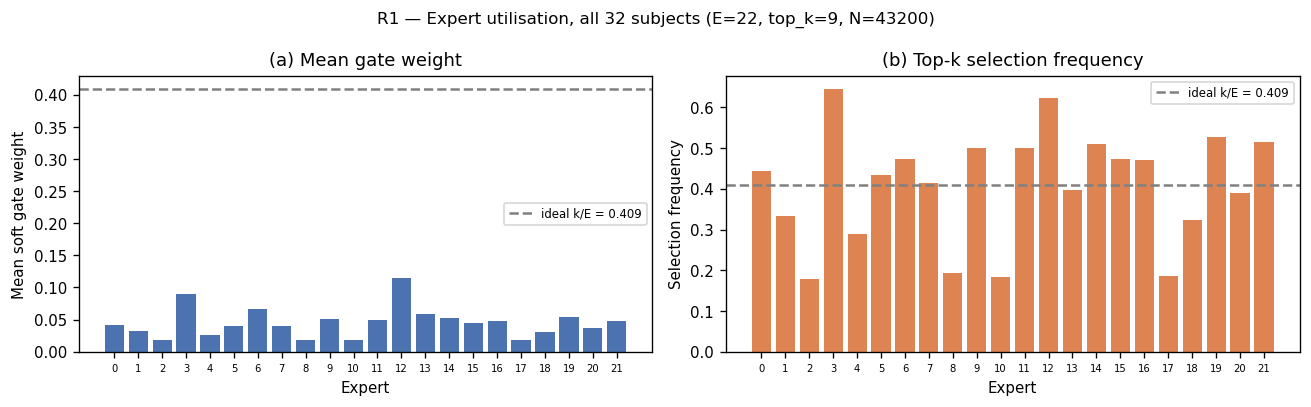

In [18]:
# ── R1: load balance, all 32 subjects ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x = np.arange(E)
axes[0].bar(x, SOFT_ALL, color='#4C72B0')
axes[0].axhline(TOPK/E, ls='--', c='gray', label=f'ideal k/E = {TOPK/E:.3f}')
axes[0].set(xlabel='Expert', ylabel='Mean soft gate weight', title='(a) Mean gate weight')
axes[1].bar(x, SEL_ALL, color='#DD8452')
axes[1].axhline(TOPK/E, ls='--', c='gray', label=f'ideal k/E = {TOPK/E:.3f}')
axes[1].set(xlabel='Expert', ylabel='Selection frequency', title='(b) Top-k selection frequency')
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels([str(i) for i in range(E)], fontsize=6)
    ax.legend(fontsize=7)
fig.suptitle(f'R1 — Expert utilisation, all {len(ALL_PIDS)} subjects '
             f'(E={E}, top_k={TOPK}, N={POPULATIONS["all32"].sum()})', fontsize=10)
fig.tight_layout(); savefig(fig, 'R1_load_balance'); plt.show()

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\R2_entropy.png


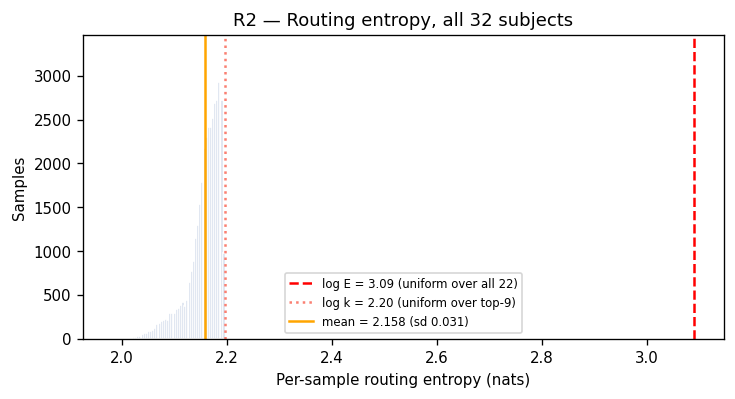

In [19]:
# ── R2: entropy histogram ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.2, 3.4))
h_all = entropy_nats(GW_ALL)
ax.hist(h_all, bins=60, color='#4C72B0', edgecolor='white')
ax.axvline(log_E, c='red',    ls='--', label=f'log E = {log_E:.2f} (uniform over all {E})')
ax.axvline(log_k, c='salmon', ls=':',  label=f'log k = {log_k:.2f} (uniform over top-{TOPK})')
ax.axvline(h_all.mean(), c='orange', label=f'mean = {h_all.mean():.3f} (sd {h_all.std():.3f})')
ax.set(xlabel='Per-sample routing entropy (nats)', ylabel='Samples',
       title=f'R2 — Routing entropy, all {len(ALL_PIDS)} subjects')
ax.legend(fontsize=7)
fig.tight_layout(); savefig(fig, 'R2_entropy'); plt.show()

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\R3_subject_x_expert.png


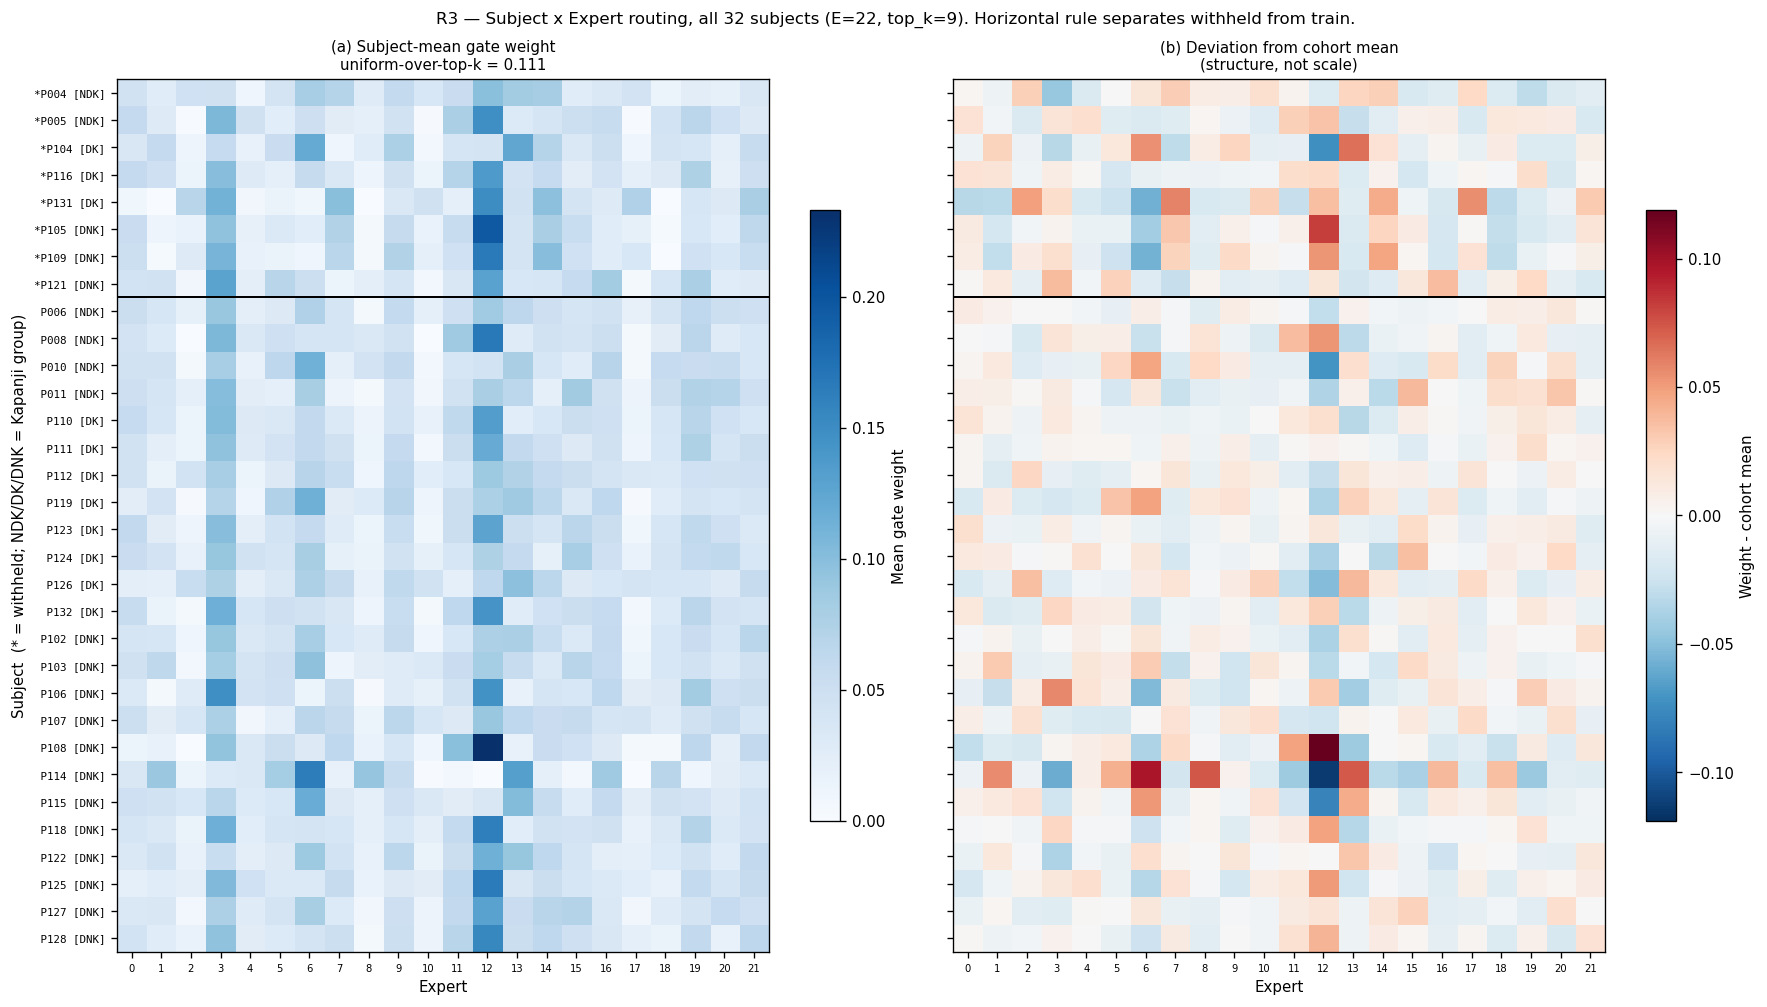

In [20]:
# ── R3: Subject x Expert heatmap (THE rebuttal figure) ──────────────────────
R    = SUBJ_RESULTS['all32']
Wm   = R['W_mean']
subj = list(R['subj_list'])

group_order = list(KAPANJI_GROUPS.keys())
order = sorted(range(len(subj)), key=lambda i: (
    0 if subj[i] in WITHHELD_PIDS else 1,
    group_order.index(pid_to_kapanji[subj[i]]),
    subj[i]))
Wm_s   = Wm[order]
labels = [f"{'*' if subj[i] in WITHHELD_PIDS else ' '}{subj[i]} "
          f"[{GROUP_ABBREV[pid_to_kapanji[subj[i]]]}]" for i in order]

fig, axes = plt.subplots(1, 2, figsize=(15, 8.5),
                         gridspec_kw={'width_ratios': [1, 1]})

im0 = axes[0].imshow(Wm_s, aspect='auto', cmap='Blues', vmin=0)
axes[0].set_title(f'(a) Subject-mean gate weight\n'
                  f'uniform-over-top-k = {1/TOPK:.3f}', fontsize=9)
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='Mean gate weight')

contrast = Wm_s - Wm.mean(axis=0)
v = np.abs(contrast).max()
im1 = axes[1].imshow(contrast, aspect='auto', cmap='RdBu_r', vmin=-v, vmax=v)
axes[1].set_title('(b) Deviation from cohort mean\n(structure, not scale)', fontsize=9)
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='Weight - cohort mean')

for j, ax in enumerate(axes):
    ax.set_xticks(range(E)); ax.set_xticklabels([str(i) for i in range(E)], fontsize=6)
    ax.set_xlabel('Expert')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels if j == 0 else [], fontsize=6.5, family='monospace')
    ax.axhline(len(WITHHELD_PIDS) - 0.5, c='k', lw=1.2)
    if j == 0:
        ax.set_ylabel('Subject  (* = withheld; NDK/DK/DNK = Kapanji group)')

fig.suptitle(f'R3 — Subject x Expert routing, all {len(subj)} subjects '
             f'(E={E}, top_k={TOPK}). Horizontal rule separates withheld from train.',
             fontsize=10)
fig.tight_layout(); savefig(fig, 'R3_subject_x_expert'); plt.show()

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\R4_cosine_and_margin.png


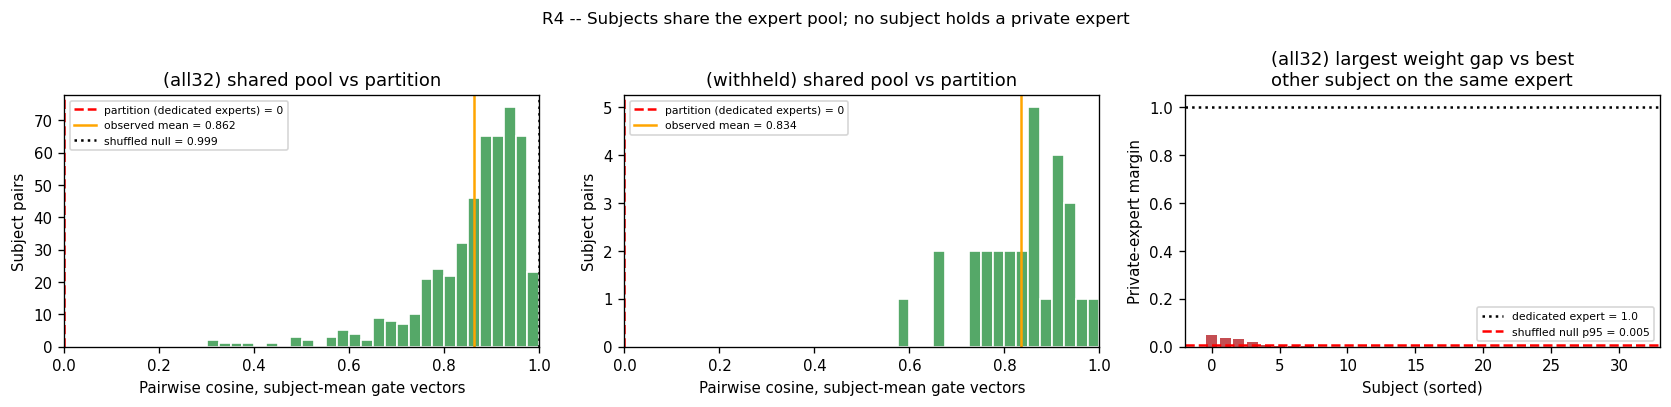

Top-k set overlap (all32) = 5.216/9 -- Claim D descriptive
only. Not plotted as evidence: this statistic rises under dedication.


In [21]:
# -- R4: subject-vector cosine similarity + private-expert margin -----------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))

for ax, pop in zip(axes[:2], ['all32', 'withheld']):
    c = SUBJ_RESULTS[pop]['cos']
    ax.hist(c, bins=40, range=(0, 1), color='#55A868', edgecolor='white')
    ax.axvline(0.0, c='red', ls='--', label='partition (dedicated experts) = 0')
    ax.axvline(c.mean(), c='orange', label=f'observed mean = {c.mean():.3f}')
    if pop == 'all32' and 'null_cosine_mean' in CLAIMS:
        ax.axvline(CLAIMS['null_cosine_mean'], c='k', ls=':',
                   label=f"shuffled null = {CLAIMS['null_cosine_mean']:.3f}")
    ax.set(xlabel='Pairwise cosine, subject-mean gate vectors',
           ylabel='Subject pairs', title=f'({pop}) shared pool vs partition', xlim=(0, 1))
    ax.legend(fontsize=6.5)

R = SUBJ_RESULTS['all32']
order_m = np.argsort(-R['margins'])
axes[2].bar(np.arange(len(order_m)), R['margins'][order_m], color='#C44E52')
axes[2].axhline(1.0, c='k', ls=':', label='dedicated expert = 1.0')
if 'null_margin_p95' in CLAIMS:
    axes[2].axhline(CLAIMS['null_margin_p95'], c='red', ls='--',
                    label=f"shuffled null p95 = {CLAIMS['null_margin_p95']:.3f}")
axes[2].set(xlabel='Subject (sorted)', ylabel='Private-expert margin',
            title='(all32) largest weight gap vs best\nother subject on the same expert',
            ylim=(0, 1.05))
axes[2].legend(fontsize=6.5)

fig.suptitle('R4 -- Subjects share the expert pool; no subject holds a private expert',
             fontsize=10)
fig.tight_layout(); savefig(fig, 'R4_cosine_and_margin'); plt.show()

print(f"Top-k set overlap (all32) = {R['overlap'].mean():.3f}/{TOPK} -- Claim D descriptive")
print("only. Not plotted as evidence: this statistic rises under dedication.")

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\R5_ownership.png


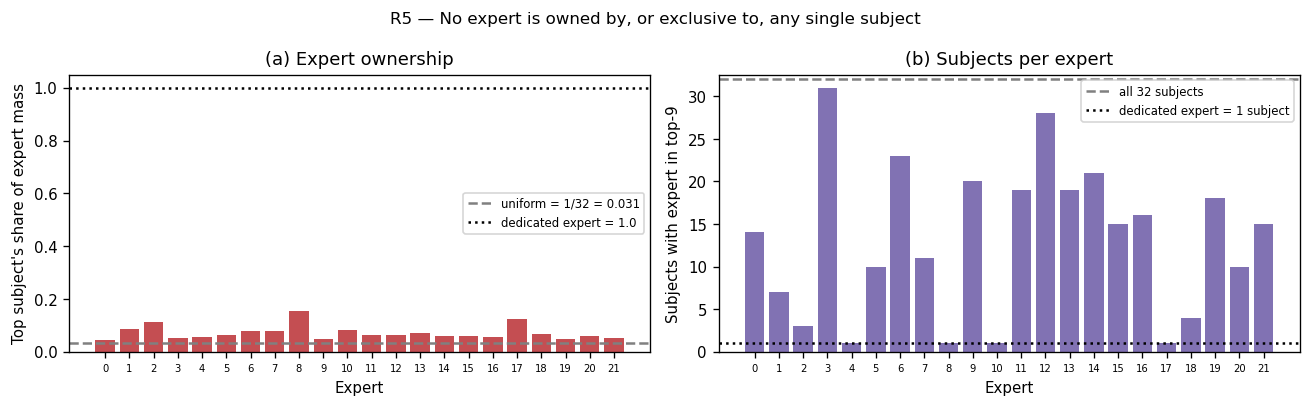

In [22]:
# ── R5: expert ownership + subjects per expert ──────────────────────────────
R = SUBJ_RESULTS['all32']
S = len(R['subj_list'])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x = np.arange(E)

axes[0].bar(x, R['own_max_per_e'], color='#C44E52')
axes[0].axhline(1/S, ls='--', c='gray', label=f'uniform = 1/{S} = {1/S:.3f}')
axes[0].axhline(1.0, ls=':', c='k', label='dedicated expert = 1.0')
axes[0].set(xlabel='Expert', ylabel="Top subject's share of expert mass",
            title='(a) Expert ownership', ylim=(0, 1.05))

axes[1].bar(x, R['in_topk'], color='#8172B3')
axes[1].axhline(S, ls='--', c='gray', label=f'all {S} subjects')
axes[1].axhline(1, ls=':', c='k', label='dedicated expert = 1 subject')
axes[1].set(xlabel='Expert', ylabel=f'Subjects with expert in top-{TOPK}',
            title='(b) Subjects per expert')

for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels([str(i) for i in range(E)], fontsize=6)
    ax.legend(fontsize=7)
fig.suptitle('R5 — No expert is owned by, or exclusive to, any single subject', fontsize=10)
fig.tight_layout(); savefig(fig, 'R5_ownership'); plt.show()

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\R6_probes.png


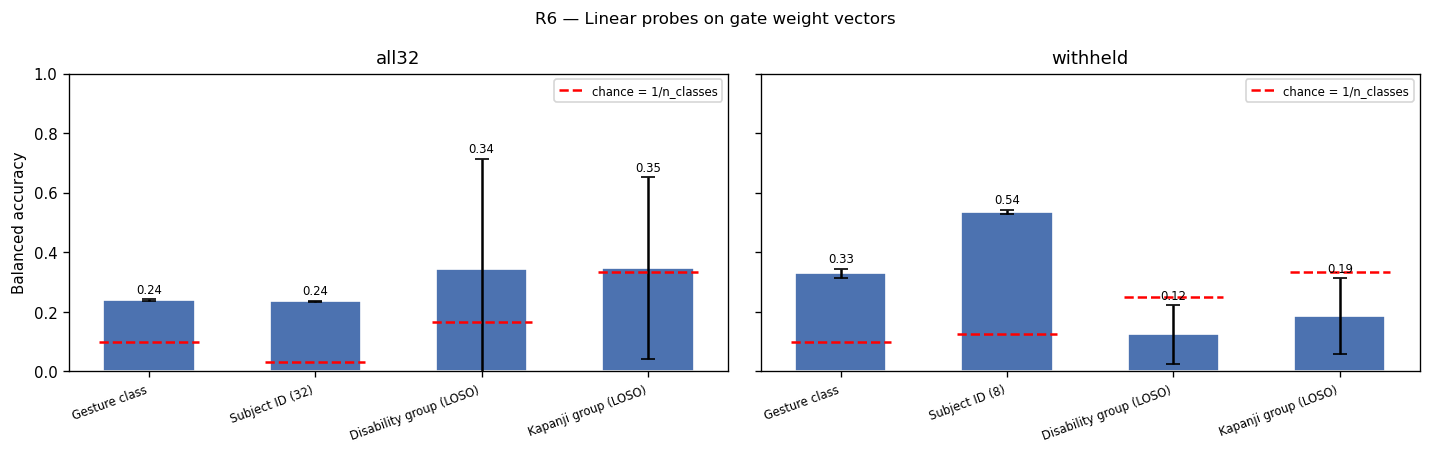

In [23]:
# ── R6: linear probes, both populations ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, pop in zip(axes, ['all32', 'withheld']):
    res = PROBES[pop]
    xs  = np.arange(len(res))
    ax.bar(xs, [r['mean'] for r in res], 0.55,
           yerr=[r['std'] for r in res], capsize=4, color='#4C72B0', edgecolor='white')
    for xi, r in zip(xs, res):
        ax.plot([xi-0.3, xi+0.3], [r['chance']]*2, c='red', lw=1.5, ls='--')
        ax.text(xi, r['mean']+r['std']+0.02, f"{r['mean']:.2f}", ha='center', fontsize=7)
    ax.plot([], [], c='red', lw=1.5, ls='--', label='chance = 1/n_classes')
    ax.set_xticks(xs)
    ax.set_xticklabels([r['name'] for r in res], rotation=20, ha='right', fontsize=7)
    ax.set(title=f'{pop}', ylim=(0, 1.0))
    ax.legend(fontsize=7)
axes[0].set_ylabel('Balanced accuracy')
fig.suptitle('R6 — Linear probes on gate weight vectors', fontsize=10)
fig.tight_layout(); savefig(fig, 'R6_probes'); plt.show()

---
## 16. Auto-generated rebuttal text

Numbers are substituted from `CLAIMS`. Read it, then we iterate on the wording — the
numbers will tell us which framing is actually defensible. Nothing here is safe to paste
before you've looked at the permutation null in 11b and the verdict in Claim G.

In [24]:
def fmt(k, spec='.3f', default='??'):
    v = CLAIMS.get(k)
    if v is None:
        return default
    return format(v, spec) if isinstance(v, float) else str(v)

print("=" * 78)
print("REBUTTAL PARAGRAPH — subject-level routing")
print("=" * 78)
print(f"""
We agree that global load balancing is insufficient here, and we want to be explicit
about why: with E={fmt('E')} experts and {fmt('n_subjects_all')} subjects, an assignment
in which every subject routed to its own private expert would place roughly 1/E of the
gate mass on each expert and would therefore satisfy the auxiliary balance objective
exactly. Balance is an average over subjects; the reviewer is asking about the
subject-conditional distribution. We have added the following subject-level analysis.

Routing is top-k with k={fmt('TOPK')}, verified empirically: {CLAIMS.get('frac_exact_topk',0)*100:.2f}%
of samples activate exactly {fmt('TOPK')} experts, so a literal single-expert-per-subject
assignment is not representable. Measured mean per-sample routing entropy over all
{fmt('n_subjects_all')} subjects is {fmt('H_mean')} nats (sd {fmt('H_std')}) against a
top-k ceiling of log {fmt('TOPK')} = {fmt('log_k')} and log E = {fmt('log_E')}; the
largest gate weight observed on any single expert for any sample is
{fmt('pmax_emp')} (mean {fmt('pmax_mean')}, p99.9 {fmt('pmax_p999')}).

At the subject level we test directly for a private expert. For each subject we take the
largest gap between its mean weight on an expert and the best other subject's weight on
that same expert; a dedicated expert produces a gap approaching 1.0. The largest such gap
over all {fmt('n_subjects_all')} subjects is {fmt('margin_max')}, against a
label-permutation null of {fmt('null_margin_mean')} (95th percentile
{fmt('null_margin_p95')}). The largest subject-mean weight on any single expert is
{fmt('conc_max')} (subject {CLAIMS.get('conc_argmax','??')}; median across subjects
{fmt('conc_med')}), where {fmt('uniform_weight_ref')} would be uniform allocation over
the selected top-k and 1.0 a dedicated expert. No expert draws more than {fmt('own_max')}
of its gate mass from any single subject (median {fmt('own_med')}; permutation null
{fmt('null_own_mean')}). Pairwise cosine similarity between subject-mean gate vectors is
{fmt('cos_mean')} on average (min {fmt('cos_min')}); a per-subject expert assignment
would drive this toward 0. Every expert is used by at least {fmt('subj_using_min')} of
the {fmt('n_subjects_all')} subjects. Independently of the
per-subject aggregation, the least-used expert is selected on {fmt('sel_min')} of all
samples while no subject contributes more than {fmt('max_subj_share','.4f')} of samples,
so it must be selected by at least {fmt('bound_min')} distinct subjects.

A linear probe on the gate vector recovers subject identity at
{fmt('probe_subj')} +/- {fmt('probe_subj_sd')} balanced accuracy
(chance {fmt('probe_subj_chance')}), and gesture class at {fmt('probe_gest')}
(chance {fmt('probe_gest_chance')}). Subject identity accounts for
{fmt('eta_subj','.1%')} of the variance in gate weights and gesture class for
{fmt('eta_gest','.1%')}. Taken together, routing is subject-dependent but implements a
graded reweighting of a shared expert pool rather than a per-subject expert assignment.
We report these statistics over all {fmt('n_subjects_all')} subjects, including training
subjects, since expert dedication would arise during training and cannot be detected on
withheld subjects alone; the withheld-{fmt('n_subjects_withheld')} values are consistent
(concentration {fmt('conc_max_wh')}, cosine {fmt('cos_mean_wh')}).
We will add the {fmt('n_subjects_all')}-subject subject x expert routing heatmap to the
appendix in the camera-ready.
""")

print("=" * 78)
print("SANITY GATES — check before pasting anything above")
print("=" * 78)
gates = [
    ("exactly top-k active on ~all samples", CLAIMS.get('frac_exact_topk', 0) > 0.999),
    ("no dead experts",                      CLAIMS.get('n_dead_experts', 1) == 0),
    ("max subject concentration << 1.0",     CLAIMS.get('conc_max', 1) < 0.35),
    ("max expert ownership << 1.0",          CLAIMS.get('own_max', 1) < 0.20),
    ("private-expert margin small",          CLAIMS.get('margin_max', 1) < 0.25),
    ("subject cosine high (shared pool)",    CLAIMS.get('cos_mean', 0) > 0.5),
    ("every expert used by >=2 subjects",    CLAIMS.get('subj_using_min', 0) >= 2),
    ("subject sample counts balanced",
     abs(CLAIMS.get('max_subj_share', 1) - 1/len(ALL_PIDS)) < 0.005),
]
for label, ok in gates:
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
if not all(ok for _, ok in gates):
    print("\n  At least one gate failed. Do not paste the paragraph -- tell me which")
    print("  gate failed and what the number was, and we rewrite the claim.")

print("\n" + "=" * 78)
print("FULL CLAIMS DICT")
print("=" * 78)
for k in sorted(CLAIMS):
    v = CLAIMS[k]
    print(f"  {k:<26} {v:.6f}" if isinstance(v, float) else f"  {k:<26} {v}")

with open(OUT_DIR / 'rebuttal_claims.json', 'w') as f:
    json.dump({k: (float(v) if isinstance(v, (int, float, np.floating)) else str(v))
               for k, v in CLAIMS.items()}, f, indent=2)
print(f"\nWrote {OUT_DIR / 'rebuttal_claims.json'}")

REBUTTAL PARAGRAPH — subject-level routing

We agree that global load balancing is insufficient here, and we want to be explicit
about why: with E=22 experts and 32 subjects, an assignment
in which every subject routed to its own private expert would place roughly 1/E of the
gate mass on each expert and would therefore satisfy the auxiliary balance objective
exactly. Balance is an average over subjects; the reviewer is asking about the
subject-conditional distribution. We have added the following subject-level analysis.

Routing is top-k with k=9, verified empirically: 100.00%
of samples activate exactly 9 experts, so a literal single-expert-per-subject
assignment is not representable. Measured mean per-sample routing entropy over all
32 subjects is 2.158 nats (sd 0.031) against a
top-k ceiling of log 9 = 2.197 and log E = 3.091; the
largest gate weight observed on any single expert for any sample is
0.358 (mean 0.191, p99.9 0.328).

At the subject level we test directly for a private 

---
## 17. Appendix figures (existing paper claims, kept for consistency)

Gesture × Expert and co-activation, recomputed under the corrected collection
(dropout off, balanced episodes) so the appendix and the rebuttal cannot disagree.

Note the co-activation figure: with top-k=9 of 22 and near-uniform weights, negative
off-diagonal correlation is partly mechanical (selecting one expert excludes another
from the top-k). Do not read it as evidence of semantic specialisation without a
top-k-matched null.

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\A1_gesture_x_expert.png


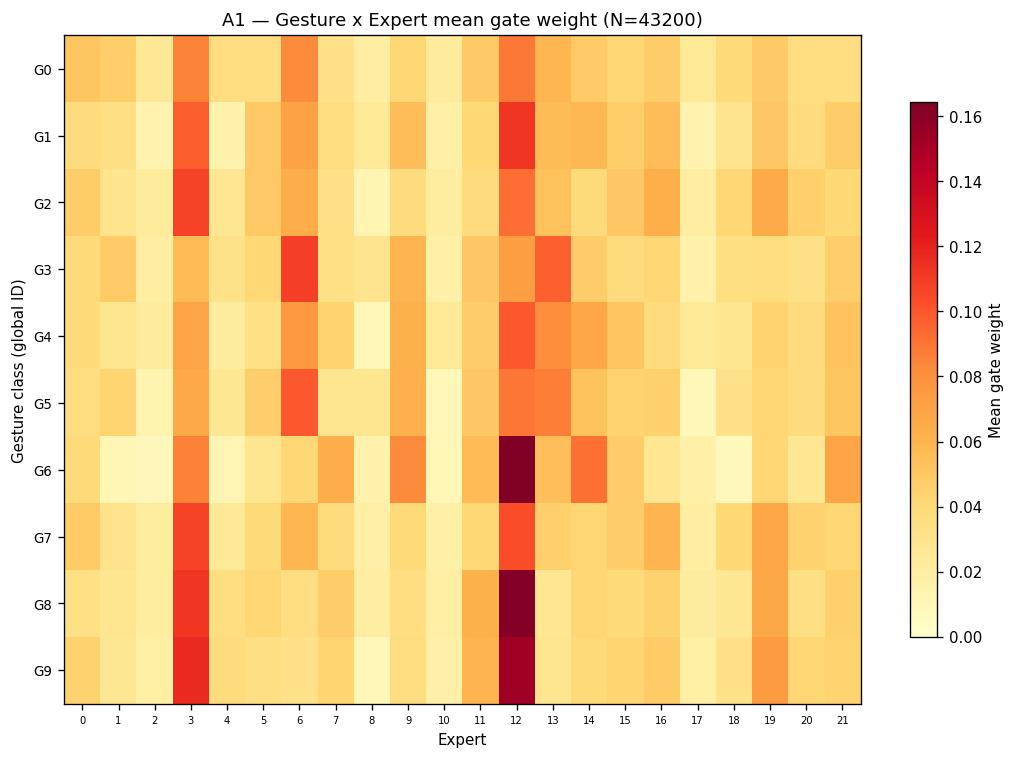

  saved C:\Users\kdmen\Repos\pers-gest-cls\paper_figures\rebuttal\A2_coactivation.png


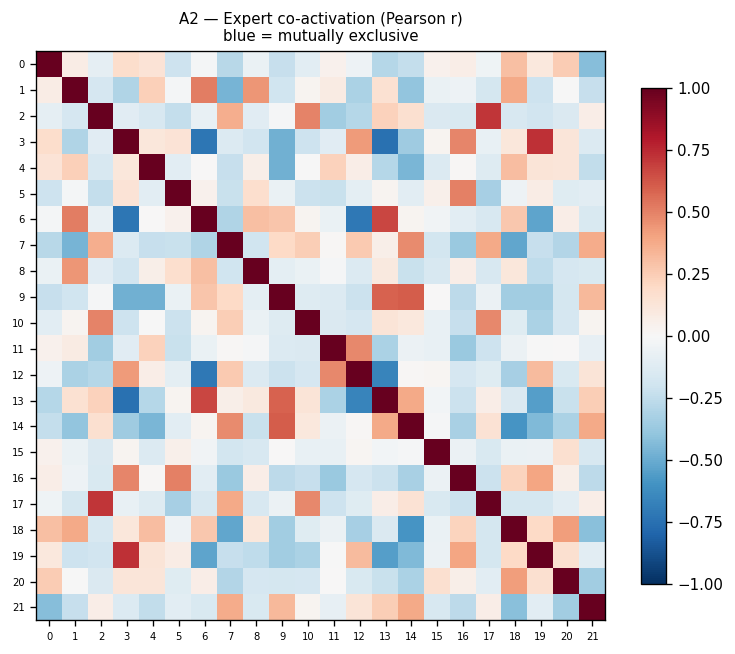

Off-diagonal r: mean -0.0452, min -0.7444, max 0.7311
Mechanical floor from top-k exclusion alone is roughly -k/(E-k) = -0.6923 for a hard-selection null.


In [25]:
# Gesture x Expert
gest_ids = sorted(set(GEST_ALL.tolist()))
Wg = np.stack([GW_ALL[GEST_ALL == g].mean(axis=0) for g in gest_ids])
fig, ax = plt.subplots(figsize=(9, 0.42*len(gest_ids)+2.2))
im = ax.imshow(Wg, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(E)); ax.set_xticklabels([str(i) for i in range(E)], fontsize=6)
ax.set_yticks(range(len(gest_ids))); ax.set_yticklabels([f'G{g}' for g in gest_ids], fontsize=8)
ax.set(xlabel='Expert', ylabel='Gesture class (global ID)',
       title=f'A1 — Gesture x Expert mean gate weight (N={len(GW_ALL)})')
plt.colorbar(im, ax=ax, shrink=0.8, label='Mean gate weight')
fig.tight_layout(); savefig(fig, 'A1_gesture_x_expert'); plt.show()

# Co-activation
C = np.corrcoef(GW_ALL.T)
fig, ax = plt.subplots(figsize=(6.4, 5.6))
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(E)); ax.set_xticklabels([str(i) for i in range(E)], fontsize=6)
ax.set_yticks(range(E)); ax.set_yticklabels([str(i) for i in range(E)], fontsize=6)
ax.set_title('A2 — Expert co-activation (Pearson r)\nblue = mutually exclusive', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); savefig(fig, 'A2_coactivation'); plt.show()

off = C[~np.eye(E, dtype=bool)]
print(f"Off-diagonal r: mean {off.mean():.4f}, min {off.min():.4f}, max {off.max():.4f}")
print(f"Mechanical floor from top-k exclusion alone is roughly -k/(E-k) = "
      f"{-TOPK/(E-TOPK):.4f} for a hard-selection null.")